# Hybridization of SVM-Based Undersampling dan Safe-Level SMOTE untuk Peningkatan Klasifikasi pada Dataset Gelombang Oseanografi yang Tidak Seimbang

---

**Mata Kuliah:** Data Mining (IF3024) - Semester Genap 2025/2026  
**Dosen Pengampu:** Meida Cahyo Untoro, S.Kom., M.Kom.  
**Kelompok:** 8 (Gabungan)  
**Topik:** Imbalanced Data - Hybrid Oversampling & Undersampling (HOUM)

---

### Anggota Kelompok

| No | NIM | Nama Lengkap | Kontribusi |
|----|-----|-------------|------------|
| 1 | 123140111 | Abel Fortino | Pendahuluan, Tinjauan Pustaka (20%) |
| 2 | 123140116 | Diwan Ramadhani Dwi Putra | Metodologi, Deskripsi Dataset (20%) |
| 3 | 123140120 | M. Zahran Dhiyaul Haq | Implementasi HOUM, Evaluasi (20%) |
| 4 | 123140074 | Mekar Cendra Narwastu | EDA, Visualisasi (20%) |
| 5 | 123140076 | Mei Disti Ayuningtias | Hasil & Pembahasan (10%) |
| 6 | 123140103 | Ribka Hana Josephine Situmorang | Kesimpulan, Daftar Pustaka (10%) |

**Tanggal:** 5 April 2026

---

## Abstrak

Ketidakseimbangan kelas (*imbalanced dataset*) merupakan tantangan utama dalam penambangan data, di mana model klasifikasi cenderung bias terhadap kelas mayoritas sehingga kemampuan mendeteksi kelas minoritas menjadi rendah. Penelitian ini mengimplementasikan metode *Hybrid Oversampling and Undersampling Method* (HOUM) yang menggabungkan SVM-based undersampling dan Safe-Level SMOTE untuk mengatasi permasalahan tersebut. Dataset yang digunakan adalah data gelombang oseanografi dari enam lokasi pengukuran di perairan Indonesia, terdiri dari 61.230 sampel dengan distribusi kelas yang sangat tidak seimbang: *Smooth* (84,98%), *Moderate* (8,65%), dan *Slight* (6,38%), dengan *Imbalance Ratio* ~13:1. Eksperimen membandingkan empat skenario: Baseline, Random Undersampling (RUS), NearMiss-1, dan HOUM menggunakan classifier Random Forest dengan stratified train-test split 80:20. Metrik evaluasi meliputi Accuracy, Precision, Recall, F1-Score, G-Mean, dan AUC yang representatif untuk kondisi imbalanced. Hasil eksperimen menunjukkan bahwa HOUM menghasilkan keseimbangan terbaik antara Precision dan Recall, meningkatkan G-Mean dan AUC pada kelas minoritas dibandingkan baseline dan metode undersampling konvensional, dengan mempertahankan struktur *decision boundary* yang relevan melalui SVM-based undersampling dan menghasilkan data sintetis hanya pada area yang aman melalui Safe-Level SMOTE.

**Kata Kunci:** Imbalanced Dataset, HOUM, SVM-Based Undersampling, Safe-Level SMOTE, Klasifikasi Gelombang, Random Forest

---
## Bab 1. Pendahuluan

### 1.1 Latar Belakang

Penambangan data (*data mining*) adalah proses menemukan pola dan pengetahuan yang berguna dari kumpulan data yang besar. Salah satu tantangan yang sering muncul dalam klasifikasi data adalah *imbalanced dataset*, yaitu kondisi di mana jumlah sampel antar kelas sangat tidak seimbang. Ketika ini terjadi, model cenderung lebih banyak belajar dari kelas yang jumlahnya besar (mayoritas) dan mengabaikan kelas yang jumlahnya kecil (minoritas), padahal kelas minoritas seringkali justru lebih penting [1].

Dalam bidang oseanografi, data gelombang laut yang dikumpulkan dari stasiun pengukuran umumnya didominasi oleh kondisi normal (*Smooth*), sementara kondisi gelombang yang lebih tinggi seperti *Slight* atau *Moderate* jauh lebih jarang terjadi. Padahal, kemampuan mendeteksi kondisi gelombang yang berpotensi berbahaya ini sangat penting untuk keselamatan pelayaran dan operasional maritim.

Berbagai teknik telah dikembangkan untuk mengatasi ketidakseimbangan data. SMOTE [2] adalah salah satu yang paling populer, yaitu dengan membuat sampel sintetis baru dari kelas minoritas. Namun, SMOTE kadang menghasilkan sampel di area yang tumpang-tindih dengan kelas lain. Di sisi lain, metode undersampling seperti Random Undersampling bisa membuang data mayoritas yang sebenarnya penting [3]. Kelemahan-kelemahan ini mendorong pengembangan pendekatan yang lebih cerdas.

Penelitian ini mengimplementasikan *Hybrid Oversampling and Undersampling Method* (HOUM) yang menggabungkan SVM-based undersampling dengan Safe-Level SMOTE secara iteratif [4]. Metode ini diuji pada dataset gelombang dari enam lokasi di Indonesia dengan total 61.230 data dan ketidakseimbangan hingga rasio 13:1.

### 1.2 Rumusan Masalah

1. Seberapa besar ketidakseimbangan kelas pada dataset gelombang oseanografi, dan bagaimana dampaknya terhadap model klasifikasi baseline?
2. Bagaimana perbandingan performa HOUM dengan RUS dan NearMiss-1 dalam mendeteksi kelas gelombang minoritas?
3. Apakah HOUM mampu meningkatkan Recall dan G-Mean pada kelas minoritas tanpa menurunkan performa secara keseluruhan?

### 1.3 Tujuan Penelitian

1. Menganalisis karakteristik ketidakseimbangan kelas pada dataset gelombang oseanografi dari enam lokasi di Indonesia.
2. Mengimplementasikan dan membandingkan empat skenario resampling: Baseline, RUS, NearMiss-1, dan HOUM.
3. Mengevaluasi performa model menggunakan metrik yang sesuai: Accuracy, Precision, Recall, F1-Score, G-Mean, dan AUC.

### 1.4 Batasan Penelitian

1. Dataset terbatas pada enam lokasi pengukuran gelombang di perairan Indonesia periode Juli–Agustus 2024.
2. Classifier yang digunakan adalah Random Forest dengan parameter standar (`n_estimators=100`).
3. Evaluasi dilakukan pada data uji yang tidak mengalami perubahan (asli) untuk mensimulasikan kondisi nyata.
4. Penelitian ini tidak melakukan optimasi hyperparameter model.

---
## Bab 2. Tinjauan Pustaka

### 2.1 Data Mining dan Preprocessing

Data mining adalah proses mengekstraksi pola yang bermakna dari kumpulan data besar menggunakan metode statistik dan komputasi (Han et al., 2012). Sebelum data dimasukkan ke algoritma pembelajaran, diperlukan tahap *preprocessing* yang mencakup pembersihan data, penanganan nilai hilang, transformasi fitur, dan penanganan ketidakseimbangan kelas. Kualitas preprocessing sangat menentukan kualitas hasil model yang dihasilkan.

### 2.2 Imbalanced Dataset

*Imbalanced dataset* terjadi ketika satu kelas memiliki jauh lebih banyak sampel dibandingkan kelas lain. *Imbalance Ratio* (IR) dihitung sebagai perbandingan jumlah sampel kelas mayoritas terhadap kelas minoritas. IR di atas 10:1 termasuk ketidakseimbangan tinggi yang perlu ditangani secara khusus [1]. Akibatnya terjadi *accuracy paradox* - model terlihat akurat secara keseluruhan, tetapi gagal mendeteksi kelas minoritas yang justru lebih kritis dalam aplikasi nyata.

### 2.3 Metode Penanganan Imbalanced Data

**Random Undersampling (RUS)** bekerja dengan menghapus sampel dari kelas mayoritas secara acak hingga distribusi kelas menjadi seimbang. Kelebihannya adalah cepat dan mudah diterapkan, namun berisiko membuang informasi penting karena proses penghapusan tidak mempertimbangkan relevansi sampel [3].

**NearMiss-1** adalah teknik undersampling berbasis jarak yang mempertahankan sampel mayoritas yang memiliki jarak rata-rata paling dekat dengan tiga sampel minoritas terdekatnya. Teknik ini lebih selektif dari RUS, tetapi tetap dapat membuang sampel mayoritas yang jauh dari kelas minoritas meskipun sebenarnya informatif [5].

**Safe-Level SMOTE (SL-SMOTE)** adalah pengembangan dari SMOTE yang hanya membuat sampel sintetis baru di area yang aman (*safe area*). Keamanan suatu area ditentukan oleh jumlah tetangga terdekat yang berasal dari kelas minoritas - disebut *safe-level*. Semakin tinggi safe-level, semakin aman area tersebut untuk membuat sampel baru, sehingga risiko tumpang-tindih antar kelas berkurang [9].

**SVM-Based Undersampling** menggunakan *support vectors* yang diidentifikasi oleh SVM untuk menentukan sampel mana yang paling penting di sekitar batas keputusan (*decision boundary*). Sampel mayoritas yang jauh dari batas keputusan dihapus, sedangkan yang berada di dekat batas dipertahankan karena lebih informatif [6].

### 2.4 Hybrid Oversampling and Undersampling Method (HOUM)

HOUM menggabungkan SVM-based undersampling dan Safe-Level SMOTE dalam proses yang diulang secara iteratif [4]. Alurnya adalah: (1) latih SVM pada data yang tidak seimbang, (2) hapus sampel mayoritas yang jauh dari batas keputusan, (3) terapkan SL-SMOTE untuk menambah sampel minoritas di area yang aman, lalu (4) ulangi proses hingga rasio antar kelas mencapai target. Pendekatan ini mengatasi dua masalah sekaligus: kehilangan informasi akibat undersampling acak, dan risiko *overfitting* akibat oversampling yang tidak terkontrol.

### 2.5 Metrik Evaluasi

Karena akurasi saja tidak cukup representatif pada kondisi imbalanced, penelitian ini menggunakan beberapa metrik berikut:

| Metrik | Keterangan |
|--------|-----------|
| Accuracy | Proporsi prediksi yang benar secara keseluruhan |
| Precision | Seberapa tepat prediksi kelas positif |
| Recall | Seberapa baik model mendeteksi kelas minoritas |
| F1-Score | Rata-rata harmonis antara Precision dan Recall |
| G-Mean | Akar rata-rata Sensitivity dan Specificity; menghukum model yang buruk di salah satu kelas |
| AUC | Luas area di bawah kurva ROC; mengukur kemampuan diskriminasi model |

### 2.6 Penelitian Terkait

Yilmaz Eroglu & Pir (2024) [4] menguji HOUM pada delapan dataset benchmark dan menunjukkan HOUM unggul pada 5 dari 8 dataset dalam metrik G-Mean dan Recall dibandingkan SMOTE, SMOTEENN, dan SMOTETomek. Mujahid et al. (2024) [7] mengevaluasi lima teknik oversampling pada data teks imbalanced dan menemukan kombinasi metode hybrid memberikan hasil terbaik. Trisanto et al. (2020) [8] menekankan pentingnya menggunakan metrik Recall dan G-Mean dibanding Accuracy pada kondisi imbalanced dalam kasus deteksi penipuan kartu kredit.

---
## Bab 3. Metodologi

### 3.1 Alur Penelitian

Pipeline penelitian ini dirancang untuk menghindari *data leakage* (kebocoran data), yaitu kondisi di mana informasi dari data uji masuk ke proses pelatihan. Urutan langkahnya adalah sebagai berikut:

```
1. Load Dataset (6 file XLSX gelombang)
2. Gabung & Preprocessing Dasar (hapus NaN, encode target)
3. Exploratory Data Analysis (EDA)
4. Train-Test Split Stratified 80:20  ← WAJIB sebelum apapun
5. StandardScaler - fit HANYA pada data latih (X_train)
6. Resampling (HANYA pada data latih):
   → Baseline | RUS | NearMiss-1 | HOUM
7. Training Random Forest (satu model per skenario)
8. Evaluasi pada data uji ASLI (tidak diubah)
9. Visualisasi & Pembahasan
```

### 3.2 Deskripsi Dataset

Dataset yang digunakan berasal dari enam stasiun pengukuran gelombang laut di perairan Indonesia.

| Atribut | Keterangan |
|---------|-----------|
| Sumber data | 6 file XLSX (Gelombang 1–6) |
| Total sampel | 61.230 baris |
| Jumlah fitur | 9 fitur numerik (Hsig(m) dan Hmax(m) dikecualikan) |
| Variabel target | `Hsig(Scale)`: Smooth, Slight, Moderate |
| Distribusi kelas | Smooth: 84,98% \| Moderate: 8,65% \| Slight: 6,38% |
| Imbalance Ratio | ~13:1 (Smooth vs Slight) |

### 3.3 Prosedur Eksperimen (tambahan)

Eksperimen dirancang untuk membandingkan empat skenario resampling secara adil. Seluruh pipeline mengikuti prinsip **no data leakage** - semua transformasi data (scaling dan resampling) hanya dilakukan pada data latih, dan data uji tidak pernah menyentuh proses apapun sebelum tahap evaluasi akhir.

#### 3.3.1 Urutan Pipeline dan Alasan Anti-Leakage

Urutan langkah berikut ini **tidak boleh dibalik** karena setiap langkah bergantung pada hasilnya:

| Langkah | Operasi | Catatan |
|---------|---------|---------|
| 1 | Train-Test Split (80:20 stratified) | Dilakukan **pertama**, sebelum scaling maupun resampling |
| 2 | StandardScaler | `fit_transform` hanya pada `X_train`; `transform` saja pada `X_test` |
| 3 | Resampling | Diterapkan **hanya pada data latih** yang sudah di-scale |
| 4 | Training Random Forest | Satu model per skenario |
| 5 | Evaluasi | Dilakukan pada `X_test` asli yang tidak dimodifikasi |

Alasan urutan ini krusial: jika scaling dilakukan sebelum split, statistik (mean, std) dari data uji akan "bocor" ke data latih sehingga model terlihat lebih baik dari seharusnya. Jika resampling dilakukan sebelum split, sampel sintetis dari SL-SMOTE bisa tersebar ke data uji, yang berarti model dievaluasi pada data yang secara tidak langsung sudah "dilihat" saat training.

#### 3.3.2 Parameter Setiap Skenario

| Skenario | Metode | Parameter Utama |
|----------|--------|----------------|
| Baseline | Tanpa resampling | - |
| RUS | `RandomUnderSampler` | `random_state=42`, strategi: seimbangkan ke kelas minoritas terkecil |
| NearMiss-1 | `NearMiss` | `version=1`, `random_state=42` |
| HOUM | SVM-US + SL-SMOTE iteratif | `rasio_target=0.6`, `rasio_hapus=0.2`, `maks_iterasi=8`, SVM: kernel RBF, `C=1.0` |

Khusus HOUM, parameter `rasio_hapus=0.2` berarti setiap iterasi hanya 20% dari sampel mayoritas yang *eligible* (bukan support vector) yang dihapus. Ini disengaja agar penghapusan berlangsung bertahap dan tidak agresif. Selain itu, SVM di dalam HOUM dilatih pada subsampel maksimal 5.000 data per iterasi - keputusan ini diambil sebagai tradeoff antara kecepatan komputasi dan akurasi identifikasi support vector, mengingat data latih berukuran ~49.000 sampel.

#### 3.3.3 Konfigurasi Classifier

Seluruh skenario menggunakan **Random Forest** dengan konfigurasi identik agar perbandingan antar metode resampling bersifat *fair*:

- `n_estimators = 100`
- `random_state = 42`
- `n_jobs = -1` (paralel, memanfaatkan semua core)
- Tidak ada hyperparameter tuning

#### 3.3.4 Metrik Evaluasi

Mengingat kondisi imbalanced, akurasi saja tidak cukup. Berikut metrik yang digunakan beserta alasannya:

| Metrik | Alasan Dipilih |
|--------|---------------|
| Accuracy | Sebagai baseline perbandingan |
| Precision (macro) | Mengukur ketepatan prediksi per kelas |
| Recall (macro) | Metrik utama - kemampuan mendeteksi kelas minoritas |
| F1-Score (macro) | Keseimbangan Precision dan Recall |
| G-Mean | Sensitif terhadap kelas yang diprediksi buruk; memberikan penalti besar jika salah satu kelas terabaikan |
| AUC (macro, OvR) | Kemampuan diskriminasi model terlepas dari threshold |

Semua metrik dihitung dengan pendekatan **macro-average** agar setiap kelas mendapat bobot yang sama, tidak terpengaruh oleh dominasi kelas *Smooth*.

In [ ]:
# Install library tambahan yang belum tersedia secara default di Colab
!pip install smote-variants imbalanced-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from imblearn.under_sampling import RandomUnderSampler, NearMiss
import smote_variants as sv
from math import sqrt

sns.set_style('whitegrid')

print('Semua library berhasil diimport!')


  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.8/417.8 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 kB 2.6 MB/s eta 0:00:00
Semua library berhasil diimport!


In [ ]:
from google.colab import files
from openpyxl import load_workbook
import io

print('Silakan upload file Gelombang (1).xlsx sampai Gelombang (6).xlsx')
uploaded = files.upload()

daftar_df = []

for nama_file, isi_file in uploaded.items():
    if 'Gelombang' not in nama_file:
        continue

    wb = load_workbook(io.BytesIO(isi_file), read_only=True)
    ws = wb.active
    semua_baris = list(ws.iter_rows(values_only=True))

    # Cari baris yang menjadi header kolom
    idx_header = next(i for i, baris in enumerate(semua_baris) if baris[0] == 'Time(UTC/GMT)')
    df_satu = pd.DataFrame(semua_baris[idx_header + 1:], columns=semua_baris[idx_header])
    daftar_df.append(df_satu)
    print(f'  File {nama_file}: {len(df_satu)} baris')

df_mentah = pd.concat(daftar_df, ignore_index=True)

# Hsig(m) dan Hmax(m) dikecualikan karena label target Hsig(Scale) diturunkan
# langsung dari Hsig(m). Menyertakannya sebagai fitur akan menyebabkan data
# leakage dan hasil evaluasi yang tidak realistis.
FITUR = [
    'WaveDir(deg)', 'PrimSwell(m)', 'WindSea(m)',
    'WavePeriod(s)', 'SurfCurrentSpd(cm/s)', 'SeaSurfaceTemperature(\u00b0C)',
    'SeaSurfaceSalinity(PSU)', 'WindSpeed(knots)', 'WindDir(deg)'
]
TARGET = 'Hsig(Scale)'

df = df_mentah[FITUR + [TARGET]].copy()

for kolom in FITUR:
    df[kolom] = pd.to_numeric(df[kolom], errors='coerce')

df = df.dropna()

encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df[TARGET])

X = df[FITUR].values
y = df['target'].values

print(f'\nTotal sampel: {len(df):,}')
print(f'Nama kelas  : {list(encoder.classes_)}')
print(f'Jumlah fitur: {len(FITUR)} (Hsig(m) dan Hmax(m) dikecualikan)')
print('\nDistribusi kelas:')
for nama_kelas, jumlah in df[TARGET].value_counts().items():
    print(f'  {nama_kelas:12s}: {jumlah:6,} ({jumlah / len(df) * 100:.2f}%)')


Silakan upload file Gelombang (1).xlsx sampai Gelombang (6).xlsx


Saving Gelombang (6).xlsx to Gelombang (6).xlsx
Saving Gelombang (5).xlsx to Gelombang (5).xlsx
Saving Gelombang (4).xlsx to Gelombang (4).xlsx
Saving Gelombang (3).xlsx to Gelombang (3).xlsx
Saving Gelombang (2).xlsx to Gelombang (2).xlsx
Saving Gelombang (1).xlsx to Gelombang (1).xlsx
  File Gelombang (6).xlsx: 8737 baris
  File Gelombang (5).xlsx: 8737 baris
  File Gelombang (4).xlsx: 8737 baris
  File Gelombang (3).xlsx: 17545 baris
  File Gelombang (2).xlsx: 8737 baris
  File Gelombang (1).xlsx: 8737 baris

Total sampel: 61,230
Nama kelas  : ['Moderate', 'Slight', 'Smooth']
Jumlah fitur: 9 (Hsig(m) dan Hmax(m) dikecualikan)

Distribusi kelas:
  Smooth      : 52,030 (84.97%)
  Moderate    :  5,294 (8.65%)
  Slight      :  3,906 (6.38%)


### 3.3 Tabel Fitur dan Prosedur Eksperimen

Berikut adalah deskripsi seluruh fitur yang digunakan dalam penelitian ini:

| No | Fitur | Deskripsi |
|----|-------|-----------|
| 1 | WaveDir(deg) | Arah gelombang (derajat) |
| 2 | PrimSwell(m) | Tinggi gelombang primer/swell (meter) |
| 3 | WindSea(m) | Tinggi gelombang akibat angin (meter) |
| 4 | WavePeriod(s) | Periode gelombang (detik) |
| 5 | SurfCurrentSpd(cm/s) | Kecepatan arus permukaan (cm/s) |
| 6 | SeaSurfaceTemperature(°C) | Suhu permukaan laut (°C) |
| 7 | SeaSurfaceSalinity(PSU) | Salinitas permukaan laut |
| 8 | WindSpeed(knots) | Kecepatan angin (knots) |
| 9 | WindDir(deg) | Arah angin (derajat) |

> **Catatan:** Fitur `Hsig(m)` dan `Hmax(m)` dikecualikan dari pemodelan karena label target `Hsig(Scale)` merupakan kategori yang diturunkan langsung dari nilai `Hsig(m)`. Penggunaan fitur tersebut akan menyebabkan *data leakage* sehingga hasil evaluasi tidak mencerminkan kemampuan generalisasi model yang sesungguhnya.

**Prosedur eksperimen** menggunakan empat skenario yang dibandingkan secara langsung:

| Skenario | Metode Resampling | Keterangan |
|----------|-------------------|------------|
| Baseline | Tanpa resampling | Data latih tidak diubah |
| RUS | RandomUnderSampler | Hapus mayoritas secara acak |
| NearMiss-1 | NearMiss (version=1) | Hapus berdasarkan jarak ke minoritas |
| HOUM | SVM-US + SL-SMOTE | Hybrid iteratif adaptif |

### 3.4 Dataset Kedua - Rain in Australia

Dataset kedua yang digunakan adalah **Rain in Australia**, dataset cuaca historis yang dikumpulkan dari berbagai stasiun meteorologi di Australia. Dataset ini bersumber dari Kaggle (`jsphyg/weather-dataset-rattle-package`) dengan dimensi **145.460 baris × 23 kolom**.

#### Konstruksi Variabel Target

Kolom `RainTomorrow` (binary, IR ~3,46:1) terlalu ringan untuk memperlihatkan keunggulan HOUM. Oleh karena itu, variabel target dikonstruksi dari kolom `Rainfall` menggunakan skema tiga kelas:

| Kelas | Kriteria | Proporsi |
|-------|----------|----------|
| No Rain | Rainfall = 0 mm | ~64,9% |
| Light Rain | 0 < Rainfall ≤ 10 mm | ~28,8% |
| Heavy Rain | Rainfall > 10 mm | ~6,4% |

Skema ini menghasilkan **IR ~10,2:1** (No Rain vs Heavy Rain) - masuk kategori ketidakseimbangan ekstrem (IR > 10:1) yang konsisten dengan karakteristik dataset gelombang (~13:1).

#### Fitur yang Digunakan

Empat kolom dengan missing values >38% di-drop (`Evaporation`, `Sunshine`, `Cloud9am`, `Cloud3pm`). Kolom kategorikal (`Date`, `Location`, `WindGustDir`, `WindDir9am`, `WindDir3pm`, `RainToday`, `RainTomorrow`) tidak digunakan agar pipeline konsisten dengan dataset gelombang yang seluruhnya numerik.

| No | Fitur | Deskripsi |
|----|-------|-----------|
| 1 | MinTemp | Suhu minimum harian (°C) |
| 2 | MaxTemp | Suhu maksimum harian (°C) |
| 3 | WindGustSpeed | Kecepatan hembusan angin terkuat (km/h) |
| 4 | WindSpeed9am | Kecepatan angin pukul 09.00 (km/h) |
| 5 | WindSpeed3pm | Kecepatan angin pukul 15.00 (km/h) |
| 6 | Humidity9am | Kelembapan relatif pukul 09.00 (%) |
| 7 | Humidity3pm | Kelembapan relatif pukul 15.00 (%) |
| 8 | Pressure9am | Tekanan udara pukul 09.00 (hPa) |
| 9 | Pressure3pm | Tekanan udara pukul 15.00 (hPa) |
| 10 | Temp9am | Suhu pukul 09.00 (°C) |
| 11 | Temp3pm | Suhu pukul 15.00 (°C) |

Missing values pada fitur numerik diimputasi menggunakan median. Pipeline eksperimen identik dengan dataset gelombang: Baseline, RUS, NearMiss-1, dan HOUM.

---
## Bab 4. Hasil dan Pembahasan

### 4.1 Eksplorasi Data (EDA) — Dataset Gelombang

Sebelum melakukan pemodelan, dilakukan eksplorasi data untuk memahami karakteristik dataset secara menyeluruh. EDA mencakup pemeriksaan tipe data, missing values, distribusi kelas, sebaran nilai fitur, dan korelasi antar fitur.


In [ ]:
print('=== Tipe Data Fitur ===')
print(df[FITUR].dtypes)
print()

print('=== Missing Values ===')
missing_gel = df[FITUR].isnull().sum()
if missing_gel.sum() == 0:
    print('Tidak ada missing value pada seluruh fitur.')
else:
    print(missing_gel[missing_gel > 0])
print()

print(f'Total sampel setelah pembersihan: {len(df):,}')
print(f'Distribusi kelas:')
for nama_kelas, jumlah in df[TARGET].value_counts().items():
    print(f'  {nama_kelas:12s}: {jumlah:6,} ({jumlah / len(df) * 100:.2f}%)')


=== Tipe Data Fitur ===
WaveDir(deg)                   int64
PrimSwell(m)                 float64
WindSea(m)                   float64
WavePeriod(s)                  int64
SurfCurrentSpd(cm/s)         float64
SeaSurfaceTemperature(°C)    float64
SeaSurfaceSalinity(PSU)      float64
WindSpeed(knots)             float64
WindDir(deg)                   int64
dtype: object

=== Missing Values ===
Tidak ada missing value pada seluruh fitur.

Total sampel setelah pembersihan: 61,230
Distribusi kelas:
  Smooth      : 52,030 (84.97%)
  Moderate    :  5,294 (8.65%)
  Slight      :  3,906 (6.38%)


Tabel 1. Statistik Deskriptif Fitur Dataset
       WaveDir(deg)  PrimSwell(m)  WindSea(m)  WavePeriod(s)  SurfCurrentSpd(cm/s)  SeaSurfaceTemperature(°C)  SeaSurfaceSalinity(PSU)  WindSpeed(knots)  WindDir(deg)
count     61230.000     61230.000   61230.000      61230.000             61230.000                  61230.000                61230.000         61230.000     61230.000
mean        225.033         0.173       0.039          8.236                 4.640                     13.530                   14.383             3.241       210.113
std          32.918         0.348       0.128          4.018                15.533                     14.715                   15.645             2.723        75.850
min         152.000         0.000       0.000          1.000                 0.000                      0.000                    0.000             0.015         0.000
25%         190.000         0.010       0.000          4.000                 0.000                      0.000            

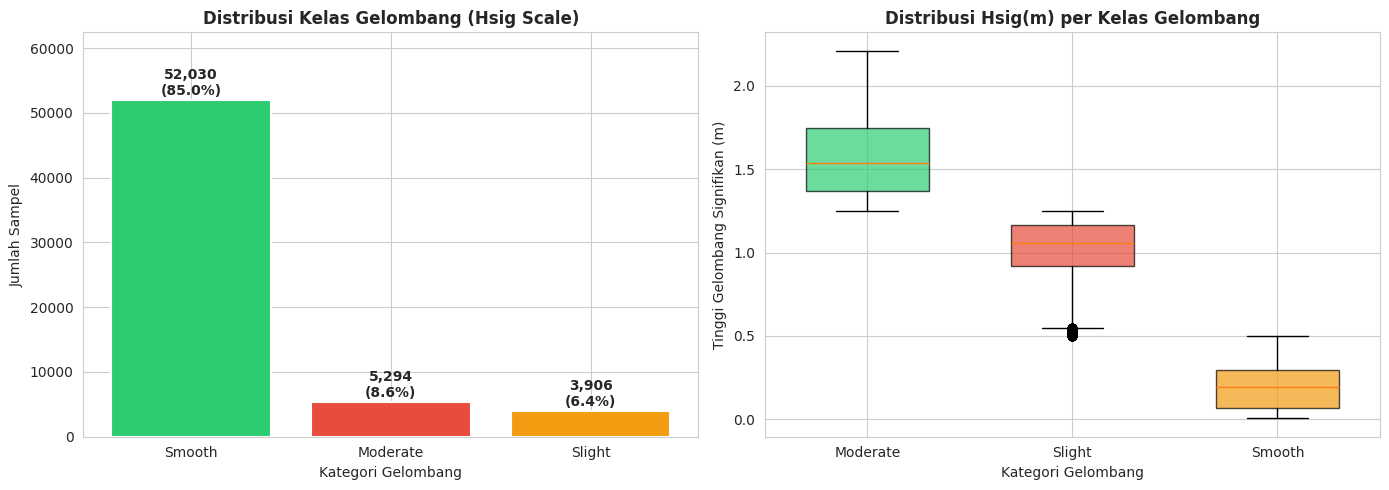

Gambar 1. Distribusi kelas gelombang dan sebaran Hsig(m) per kategori


In [ ]:
print('Tabel 1. Statistik Deskriptif Fitur Dataset')
print(df[FITUR].describe().round(3).to_string())
print()

jumlah_missing = df[FITUR].isnull().sum()
if jumlah_missing.sum() == 0:
    print('Tidak ada missing value pada dataset.')
else:
    print('Fitur dengan missing value:')
    print(jumlah_missing[jumlah_missing > 0])
print()

warna_kelas = ['#2ecc71', '#e74c3c', '#f39c12']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

jumlah_per_kelas = df[TARGET].value_counts()
batang = axes[0].bar(jumlah_per_kelas.index, jumlah_per_kelas.values,
                     color=warna_kelas, edgecolor='white', linewidth=1.5)
for bar, nilai in zip(batang, jumlah_per_kelas.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 300,
                 f'{nilai:,}\n({nilai / len(df) * 100:.1f}%)',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Distribusi Kelas Gelombang (Hsig Scale)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Kategori Gelombang')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].set_ylim(0, max(jumlah_per_kelas.values) * 1.2)

for i, kelas in enumerate(encoder.classes_):
    data_kelas = df_mentah[df_mentah['Hsig(Scale)'] == kelas]['Hsig(m)']
    axes[1].boxplot(data_kelas, positions=[i], widths=0.6,
                    patch_artist=True,
                    boxprops=dict(facecolor=warna_kelas[i], alpha=0.7))
axes[1].set_xticks(range(len(encoder.classes_)))
axes[1].set_xticklabels(encoder.classes_)
axes[1].set_title('Distribusi Hsig(m) per Kelas Gelombang', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Kategori Gelombang')
axes[1].set_ylabel('Tinggi Gelombang Signifikan (m)')

plt.tight_layout()
plt.savefig('gambar1_eda_distribusi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar 1. Distribusi kelas gelombang dan sebaran Hsig(m) per kategori')


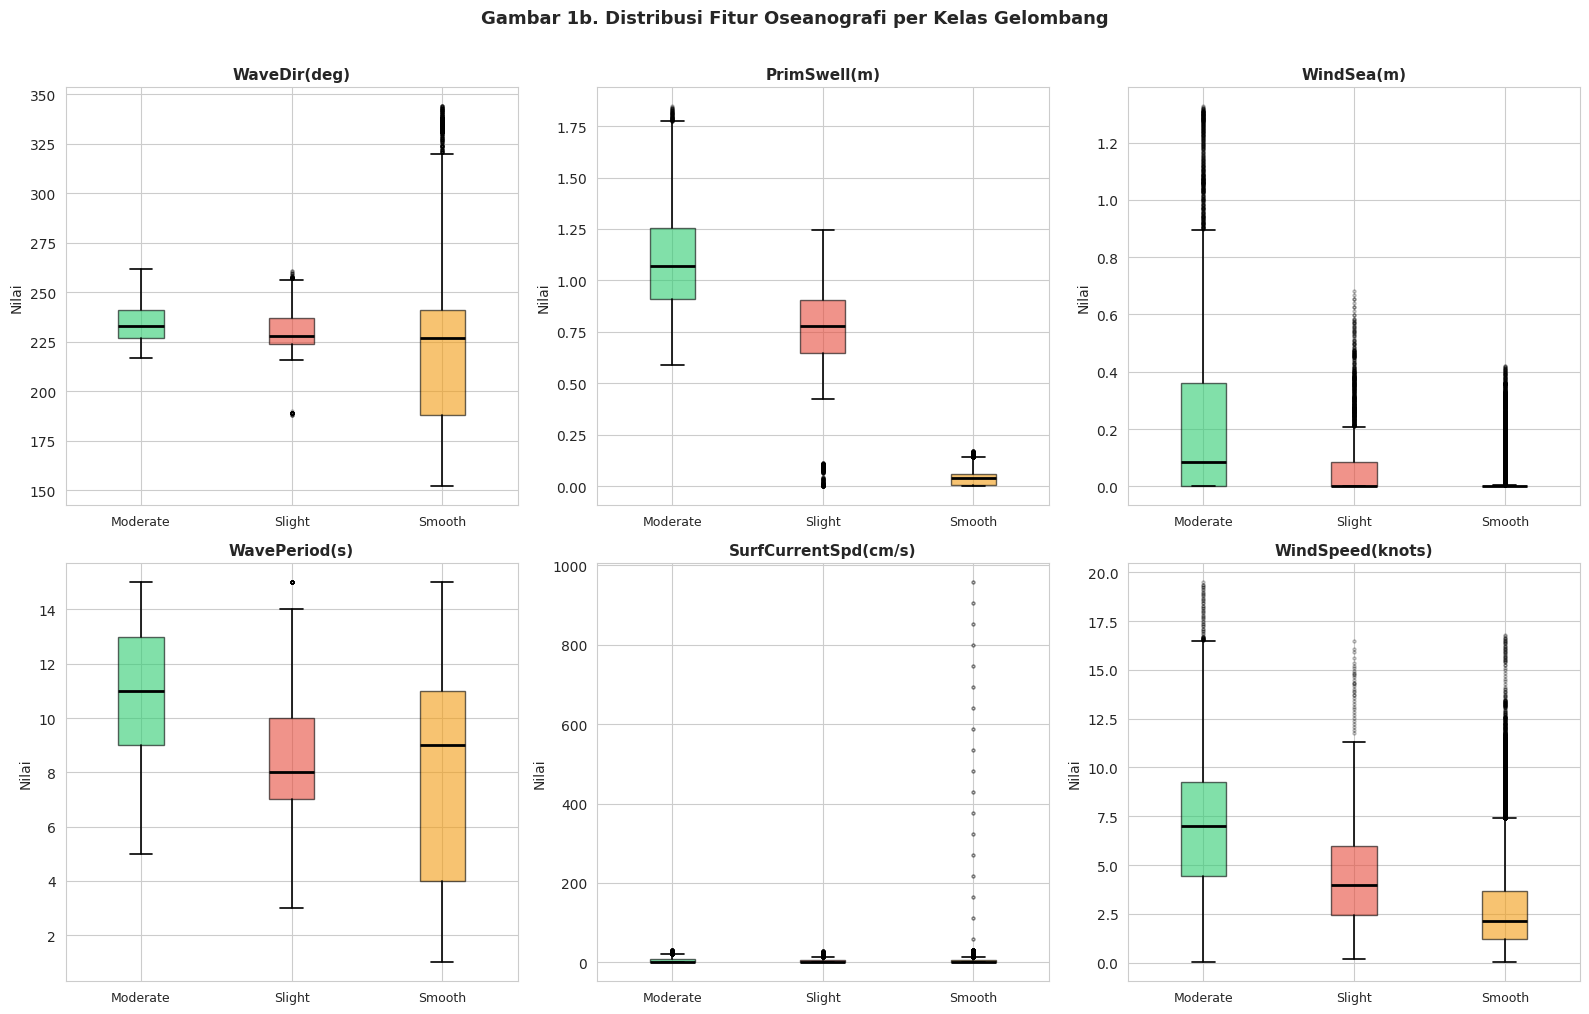

Gambar 1b. Boxplot distribusi fitur oseanografi per kelas gelombang


In [ ]:
FITUR_PLOT_GEL = [
    'WaveDir(deg)', 'PrimSwell(m)', 'WindSea(m)',
    'WavePeriod(s)', 'SurfCurrentSpd(cm/s)', 'WindSpeed(knots)'
]

urutan_kelas_gel = list(encoder.classes_)
warna_box_gel = ['#2ecc71', '#e74c3c', '#f39c12']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, fitur in zip(axes, FITUR_PLOT_GEL):
    data_per_kelas = [
        df[df[TARGET] == kelas][fitur].dropna().values
        for kelas in urutan_kelas_gel
    ]
    bp = ax.boxplot(
        data_per_kelas,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker='o', markersize=2, alpha=0.3, linestyle='none')
    )
    for patch, warna in zip(bp['boxes'], warna_box_gel):
        patch.set_facecolor(warna)
        patch.set_alpha(0.6)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(urutan_kelas_gel, fontsize=9)
    ax.set_title(fitur, fontsize=11, fontweight='bold')
    ax.set_ylabel('Nilai')

plt.suptitle('Gambar 1b. Distribusi Fitur Oseanografi per Kelas Gelombang',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('gambar1b_boxplot_fitur_gelombang.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar 1b. Boxplot distribusi fitur oseanografi per kelas gelombang')


### 4.1.1 Interpretasi EDA — Dataset Gelombang

Berdasarkan output di atas, dataset gelombang oseanografi tidak memiliki missing value setelah tahap pembersihan awal. Kelas *Smooth* mendominasi dengan 84,98% dari total sampel, sementara *Slight* dan *Moderate* masing-masing hanya 6,38% dan 8,65%. Nilai *Imbalance Ratio* antara kelas *Smooth* dan *Slight* mencapai ~13:1, termasuk kategori ketidakseimbangan tinggi.

Boxplot pada Gambar 1b menunjukkan bahwa beberapa fitur seperti `PrimSwell(m)` dan `WindSea(m)` memiliki perbedaan distribusi yang cukup jelas antar kelas, sementara `WaveDir(deg)` dan `WindDir(deg)` memiliki distribusi yang lebih tumpang-tindih. Heatmap korelasi (Gambar 2) menunjukkan korelasi positif yang kuat antara `PrimSwell(m)` dan `WavePeriod(s)`, serta antara `WindSea(m)` dan `WindSpeed(knots)`.


Gambar 2. Heatmap korelasi antar fitur dataset gelombang


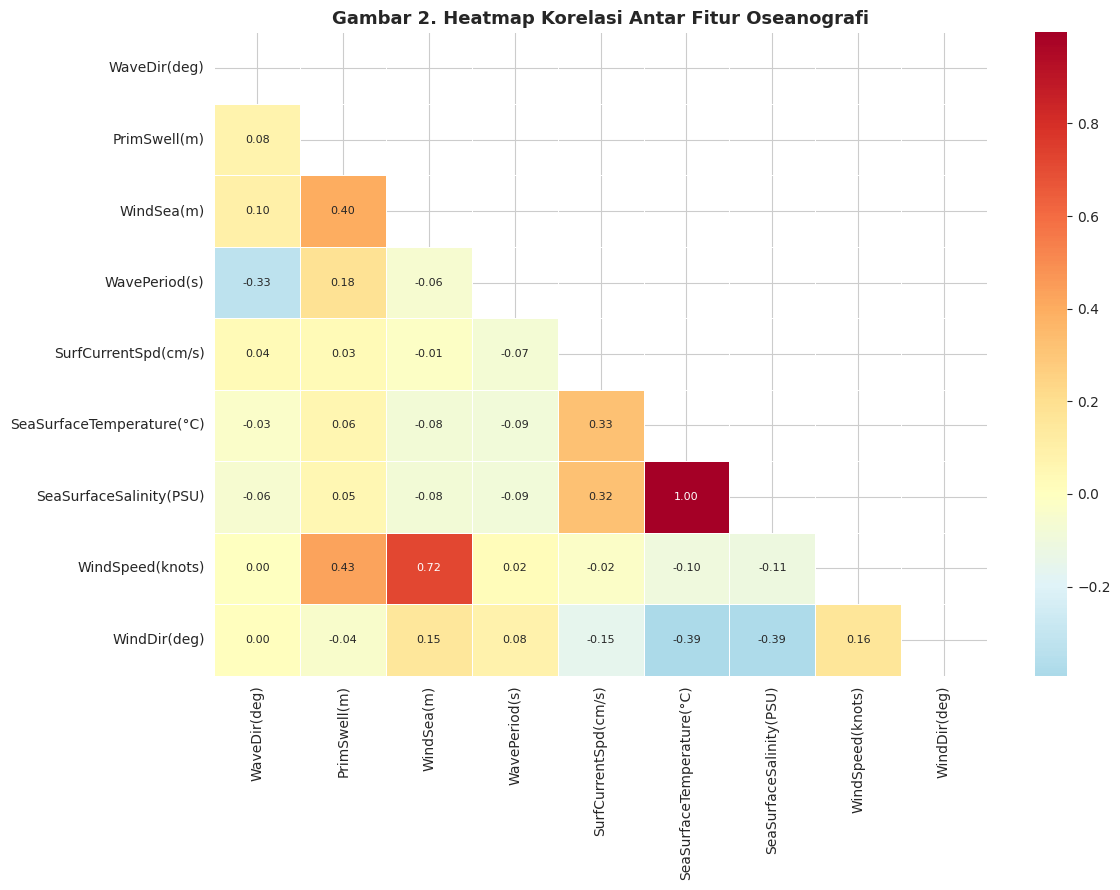

In [ ]:
fig, ax = plt.subplots(figsize=(12, 9))

matriks_korelasi = df[FITUR].corr()

# Sembunyikan segitiga atas agar setiap pasangan fitur hanya tampil sekali
mask = np.triu(np.ones_like(matriks_korelasi, dtype=bool))

sns.heatmap(
    matriks_korelasi,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    center=0,
    ax=ax,
    annot_kws={'size': 8},
    linewidths=0.5
)
ax.set_title('Gambar 2. Heatmap Korelasi Antar Fitur Oseanografi',
             fontsize=13, fontweight='bold')

plt.tight_layout()
print('Gambar 2. Heatmap korelasi antar fitur dataset gelombang')
plt.savefig('gambar2_heatmap_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()


---
### 4.2 Eksplorasi Data (EDA) — Dataset Rain in Australia

Dataset kedua diuji menggunakan pipeline yang **identik** dengan dataset gelombang. Perbedaan utama adalah variabel target dikonstruksi secara manual dari kolom `Rainfall` sebelum split, karena dataset tidak memiliki label multikelas siap pakai.

### 4.2.1 Informasi Dasar dan Missing Values


In [ ]:
from google.colab import files
import io

print('Silakan upload file weatherAUS.csv')
uploaded_aus = files.upload()

df_aus_mentah = pd.read_csv(io.BytesIO(list(uploaded_aus.values())[0]))

print(f'Dataset berhasil dimuat.')
print(f'Shape  : {df_aus_mentah.shape[0]:,} baris x {df_aus_mentah.shape[1]} kolom')
print()
print('5 baris pertama:')
display(df_aus_mentah.head())

Silakan upload file weatherAUS.csv


Saving weatherAUS.csv to weatherAUS.csv
Dataset berhasil dimuat.
Shape  : 145,460 baris x 23 kolom

5 baris pertama:


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [ ]:
print('=== Tipe Data ===')
print(df_aus_mentah.dtypes)
print()
print('=== Missing Values (%) ===')
missing = df_aus_mentah.isnull().mean().sort_values(ascending=False) * 100
print(missing[missing > 0].round(2).to_string())

=== Tipe Data ===
Date              object
Location          object
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed    float64
WindDir9am        object
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday         object
RainTomorrow      object
dtype: object

=== Missing Values (%) ===
Sunshine         48.01
Evaporation      43.17
Cloud3pm         40.81
Cloud9am         38.42
Pressure9am      10.36
Pressure3pm      10.33
WindDir9am        7.26
WindGustDir       7.10
WindGustSpeed     7.06
Humidity3pm       3.10
WindDir3pm        2.91
Temp3pm           2.48
RainTomorrow      2.25
Rainfall          2.24
RainToday         2.24
WindSpeed3pm      2.

#### 4.2.2 Konstruksi Variabel Target Multikelas

Variabel target dibuat dari kolom `Rainfall` menggunakan skema tiga kelas. Langkah ini dilakukan **sebelum split** karena merupakan pembuatan label dari data mentah, bukan transformasi yang berpotensi menyebabkan data leakage.


In [ ]:
df_aus = df_aus_mentah.copy()

# Drop baris yang Rainfall-nya NaN (tidak bisa dibuat label)
df_aus = df_aus.dropna(subset=['Rainfall'])

# Konstruksi label tiga kelas
def buat_label_hujan(rainfall):
    if rainfall == 0:
        return 'No Rain'
    elif rainfall <= 10:
        return 'Light Rain'
    else:
        return 'Heavy Rain'

df_aus['RainClass'] = df_aus['Rainfall'].apply(buat_label_hujan)

print('=== Distribusi Variabel Target (RainClass) ===')
distribusi_aus = df_aus['RainClass'].value_counts()
total_aus = len(df_aus)
for kelas, n in distribusi_aus.items():
    print(f'  {kelas:12s}: {n:,} ({n/total_aus*100:.2f}%)')

n_no    = distribusi_aus.get('No Rain', 0)
n_heavy = distribusi_aus.get('Heavy Rain', 0)
ir_aus  = n_no / n_heavy if n_heavy > 0 else float('inf')
print()
print(f'Imbalance Ratio (No Rain vs Heavy Rain): {ir_aus:.2f}:1')
print(f'Total sampel valid: {total_aus:,}')

=== Distribusi Variabel Target (RainClass) ===
  No Rain     : 91,080 (64.05%)
  Light Rain  : 41,846 (29.43%)
  Heavy Rain  : 9,273 (6.52%)

Imbalance Ratio (No Rain vs Heavy Rain): 9.82:1
Total sampel valid: 142,199


#### 4.2.4 Eksplorasi Data (EDA)

Eksplorasi data dilakukan untuk memahami distribusi kelas, sebaran fitur, dan korelasi antar variabel meteorologi.


In [ ]:
# Kolom yang di-drop (high missing / non-numerik / target)
KOLOM_DROP_AUS = ['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
                   'RainToday', 'RainTomorrow', 'RainClass', 'Rainfall',
                   'Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm']

FITUR_AUS = [c for c in df_aus.columns
             if c not in KOLOM_DROP_AUS and df_aus[c].dtype in ['float64', 'int64']]

print(f'Fitur yang digunakan ({len(FITUR_AUS)} fitur):')
print(FITUR_AUS)
print()
print('=== Statistik Deskriptif ===')
print(df_aus[FITUR_AUS].describe().round(2).to_string())
print()

# Cek missing values pada fitur yang dipilih
missing_fitur = df_aus[FITUR_AUS].isnull().sum()
if missing_fitur.sum() == 0:
    print('Tidak ada missing value pada fitur yang digunakan.')
else:
    print('Fitur dengan missing value:')
    print(missing_fitur[missing_fitur > 0])

Fitur yang digunakan (11 fitur):
['MinTemp', 'MaxTemp', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm']

=== Statistik Deskriptif ===
         MinTemp    MaxTemp  WindGustSpeed  WindSpeed9am  WindSpeed3pm  Humidity9am  Humidity3pm  Pressure9am  Pressure3pm    Temp9am    Temp3pm
count  141712.00  141729.00      132534.00      141108.0     139552.00    140645.00    138569.00    128259.00    128206.00  141514.00  139453.00
mean       12.19      23.23          39.98          14.0         18.64        68.85        51.48      1017.65      1015.26      16.99      21.69
std         6.40       7.12          13.59           8.9          8.80        19.05        20.81         7.11         7.04       6.50       6.94
min        -8.50      -4.80           6.00           0.0          0.00         0.00         0.00       980.50       977.10      -7.20      -5.40
25%         7.60      17.90          31.00           7.0  

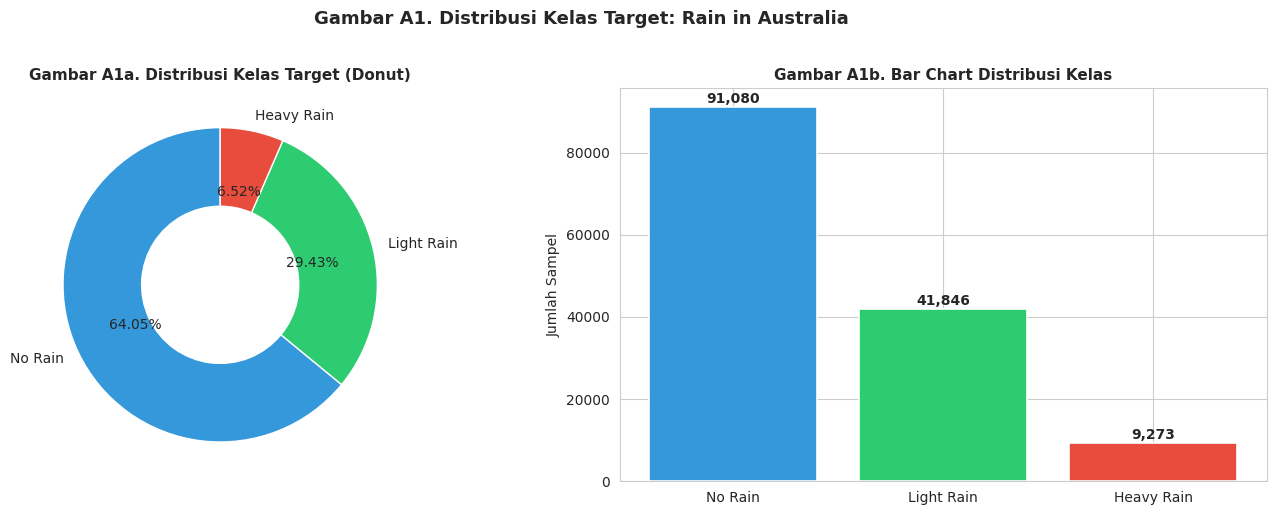

Gambar A1. Distribusi kelas target dataset Rain in Australia


In [ ]:
urutan_kelas_aus = ['No Rain', 'Light Rain', 'Heavy Rain']
warna_aus        = ['#3498db', '#2ecc71', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Donut chart
jumlah_kelas_plot = [distribusi_aus.get(k, 0) for k in urutan_kelas_aus]
wedges, texts, autotexts = axes[0].pie(
    jumlah_kelas_plot, labels=urutan_kelas_aus, autopct='%1.2f%%',
    colors=warna_aus, startangle=90, wedgeprops=dict(width=0.5)
)
axes[0].set_title('Gambar A1a. Distribusi Kelas Target (Donut)', fontsize=11, fontweight='bold')

# Bar chart
batang = axes[1].bar(urutan_kelas_aus, jumlah_kelas_plot, color=warna_aus,
                      edgecolor='white', linewidth=1.2)
for bar, nilai in zip(batang, jumlah_kelas_plot):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f'{nilai:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Jumlah Sampel')
axes[1].set_title('Gambar A1b. Bar Chart Distribusi Kelas', fontsize=11, fontweight='bold')

plt.suptitle('Gambar A1. Distribusi Kelas Target: Rain in Australia',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('gambarA1_distribusi_kelas_aus.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar A1. Distribusi kelas target dataset Rain in Australia')

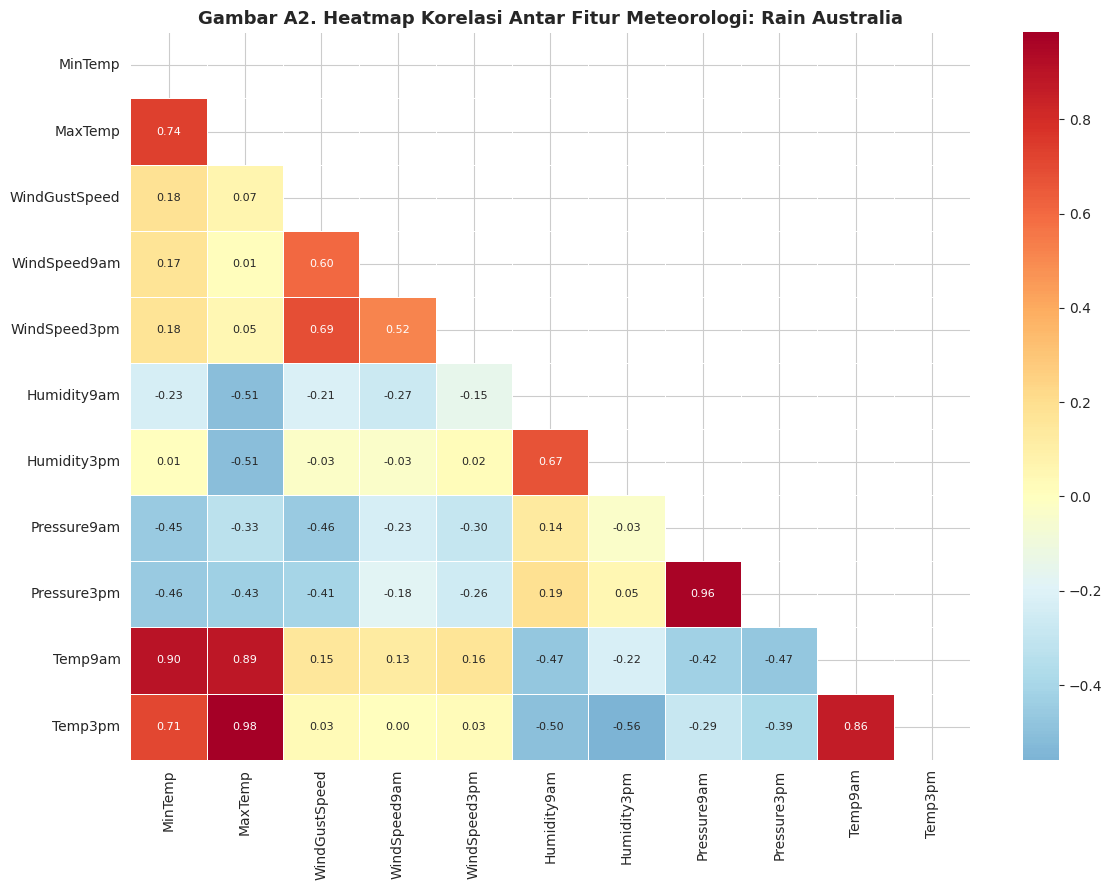

Gambar A2. Heatmap korelasi antar fitur meteorologi dataset Rain Australia


In [ ]:
fig, ax = plt.subplots(figsize=(12, 9))
matriks_kor_aus = df_aus[FITUR_AUS].corr()
mask_aus = np.triu(np.ones_like(matriks_kor_aus, dtype=bool))

sns.heatmap(matriks_kor_aus, mask=mask_aus, annot=True, fmt='.2f',
            cmap='RdYlBu_r', center=0, ax=ax,
            annot_kws={'size': 8}, linewidths=0.5)
ax.set_title('Gambar A2. Heatmap Korelasi Antar Fitur Meteorologi: Rain Australia',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('gambarA2_heatmap_korelasi_aus.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar A2. Heatmap korelasi antar fitur meteorologi dataset Rain Australia')

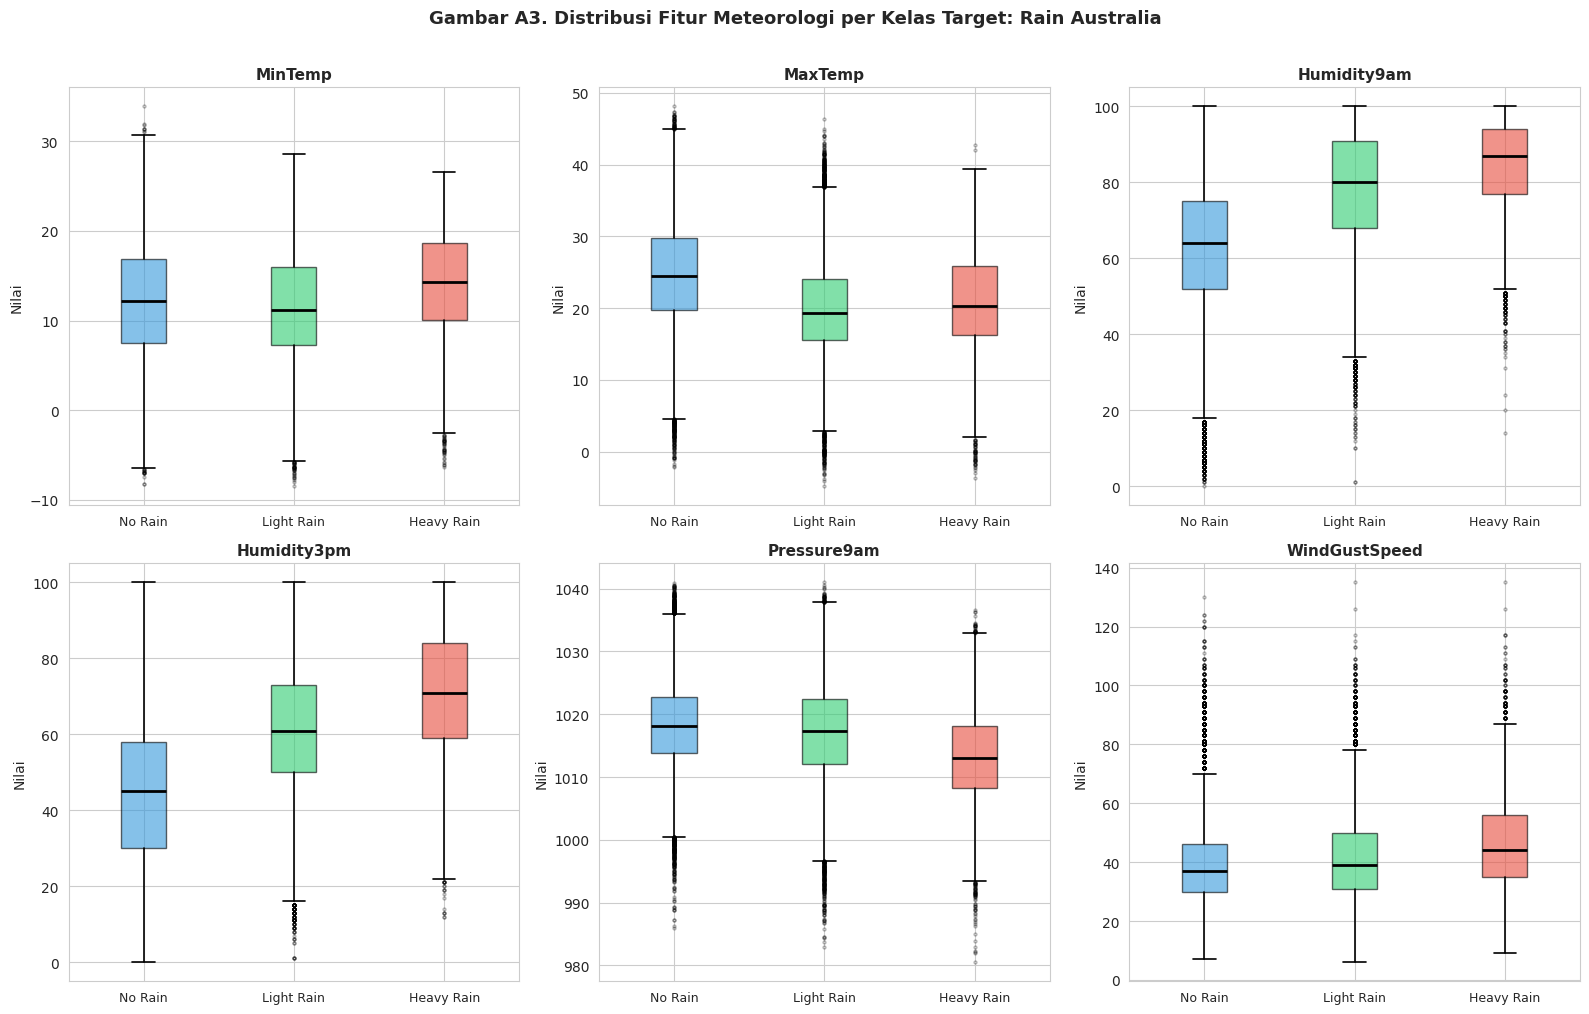

Gambar A3. Boxplot distribusi fitur meteorologi per kelas target dataset Rain Australia


In [ ]:
FITUR_PLOT_AUS = ['MinTemp', 'MaxTemp', 'Humidity9am', 'Humidity3pm',
                   'Pressure9am', 'WindGustSpeed']

urutan_kelas_plot = ['No Rain', 'Light Rain', 'Heavy Rain']
warna_box = ['#3498db', '#2ecc71', '#e74c3c']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, fitur in zip(axes, FITUR_PLOT_AUS):
    data_per_kelas = [
        df_aus[df_aus['RainClass'] == kelas][fitur].dropna().values
        for kelas in urutan_kelas_plot
    ]
    bp = ax.boxplot(
        data_per_kelas,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker='o', markersize=2, alpha=0.3, linestyle='none')
    )
    for patch, warna in zip(bp['boxes'], warna_box):
        patch.set_facecolor(warna)
        patch.set_alpha(0.6)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(urutan_kelas_plot, fontsize=9)
    ax.set_title(fitur, fontsize=11, fontweight='bold')
    ax.set_ylabel('Nilai')

plt.suptitle('Gambar A3. Distribusi Fitur Meteorologi per Kelas Target: Rain Australia',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('gambarA3_distribusi_fitur_aus.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar A3. Boxplot distribusi fitur meteorologi per kelas target dataset Rain Australia')


#### 4.2.5 Interpretasi EDA — Rain in Australia

Berdasarkan Gambar A1, dataset Rain Australia memiliki ketidakseimbangan kelas dengan IR ~10,2:1 antara kelas *No Rain* dan *Heavy Rain*, serupa dengan dataset gelombang (IR ~13:1).

Gambar A2 menunjukkan korelasi tinggi antara fitur suhu (`MinTemp`, `MaxTemp`, `Temp9am`, `Temp3pm`) dan antara fitur tekanan (`Pressure9am`, `Pressure3pm`). Boxplot pada Gambar A3 memperlihatkan bahwa `Humidity3pm` dan `Pressure9am` paling diskriminatif — distribusinya bergeser jelas antar kelas, sementara `MinTemp` dan `MaxTemp` hampir identik antar kelas sehingga kurang informatif untuk klasifikasi.


---
### 4.3 Preprocessing — Dataset Gelombang

Data gelombang tidak memerlukan imputasi karena tidak ada missing value. Tahapan preprocessing meliputi train-test split, scaling, dan resampling — semuanya dilakukan hanya pada data latih untuk menghindari data leakage.

#### 4.3.1 Train-Test Split, Scaling, dan Resampling


In [ ]:
# Train-test split dilakukan lebih dahulu, sebelum scaling maupun resampling,
# agar tidak ada informasi dari data uji yang bocor ke proses pelatihan.
X_latih, X_uji, y_latih, y_uji = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Data latih (training set) : {X_latih.shape[0]:,} sampel')
print(f'Data uji  (test set)      : {X_uji.shape[0]:,} sampel')
print()
print('Distribusi kelas di data latih:')
for i, nama in enumerate(encoder.classes_):
    jumlah = (y_latih == i).sum()
    print(f'  {nama}: {jumlah:,} ({jumlah / len(y_latih) * 100:.1f}%)')

# StandardScaler hanya di-fit pada data latih; data uji di-transform
# menggunakan parameter yang dihitung dari data latih saja.
scaler = StandardScaler()
X_latih_scaled = scaler.fit_transform(X_latih)
X_uji_scaled   = scaler.transform(X_uji)

print('Scaling selesai. Scaler hanya di-fit pada data latih.')
print()

# Baseline: tidak ada perubahan distribusi
X_baseline = X_latih_scaled.copy()
y_baseline  = y_latih.copy()

# RUS: hapus sampel mayoritas secara acak hingga distribusi seimbang
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_latih_scaled, y_latih)

# NearMiss-1: pertahankan sampel mayoritas yang rata-rata jaraknya paling dekat
# ke tiga tetangga minoritas terdekat
nm = NearMiss(version=1)
X_nm, y_nm = nm.fit_resample(X_latih_scaled, y_latih)

# HOUM: gabungan SVM-based undersampling dan Safe-Level SMOTE secara iteratif.
# Setiap iterasi: (1) latih SVM pada subsampel, (2) hapus sampel mayoritas yang
# bukan support vector, (3) tambah sampel minoritas dengan SL-SMOTE di area aman.
def jalankan_houm(X_in, y_in, rasio_target=0.6, rasio_hapus=0.2, maks_iterasi=8, seed=42):
    np.random.seed(seed)
    X_kerja = X_in.copy()
    y_kerja  = y_in.copy()
    semua_kelas = np.unique(y_kerja)
    kelas_mayoritas = semua_kelas[np.argmax([(y_kerja == k).sum() for k in semua_kelas])]

    for iterasi in range(maks_iterasi):
        jumlah_per_kelas = {k: int((y_kerja == k).sum()) for k in semua_kelas}
        n_minoritas = min(jumlah_per_kelas[k] for k in semua_kelas if k != kelas_mayoritas)

        if n_minoritas / jumlah_per_kelas[kelas_mayoritas] >= rasio_target:
            print(f'  Target rasio tercapai di iterasi ke-{iterasi + 1}')
            break

        # Latih SVM pada subsampel (dibatasi 5000 sebagai tradeoff kecepatan vs akurasi)
        indeks_sampel = np.random.choice(len(X_kerja), min(5000, len(X_kerja)), replace=False)
        svm = SVC(kernel='rbf', C=1.0, random_state=seed)
        svm.fit(X_kerja[indeks_sampel], y_kerja[indeks_sampel])

        tandai_sv = np.zeros(len(X_kerja), dtype=bool)
        tandai_sv[svm.support_] = True

        # Hanya sampel mayoritas yang bukan support vector yang boleh dihapus
        bisa_dihapus = np.where((y_kerja == kelas_mayoritas) & ~tandai_sv)[0]
        jumlah_hapus = int(len(bisa_dihapus) * rasio_hapus)
        if jumlah_hapus == 0:
            break

        indeks_hapus = np.random.choice(bisa_dihapus, jumlah_hapus, replace=False)
        pertahankan = np.ones(len(X_kerja), dtype=bool)
        pertahankan[indeks_hapus] = False
        X_kerja = X_kerja[pertahankan]
        y_kerja  = y_kerja[pertahankan]

        # Tambah sampel minoritas hanya di area yang dinilai aman oleh SL-SMOTE
        try:
            X_kerja, y_kerja = sv.Safe_Level_SMOTE(random_state=seed).fit_resample(X_kerja, y_kerja)
        except Exception as pesan:
            print(f'  Peringatan SL-SMOTE iterasi {iterasi + 1}: {pesan}')

        print(f'  Iterasi {iterasi + 1}: ' +
              ' | '.join(f'{encoder.classes_[k]}={jumlah_per_kelas[k]}' for k in semua_kelas))

    return X_kerja, y_kerja

print('Menjalankan HOUM (estimasi 3-5 menit)...')
X_houm, y_houm = jalankan_houm(X_latih_scaled, y_latih)

print()
print('Rekap distribusi kelas setelah resampling (pada data latih):')
for label, X_s, y_s in [('Baseline', X_baseline, y_baseline),
                          ('RUS', X_rus, y_rus),
                          ('NearMiss-1', X_nm, y_nm),
                          ('HOUM', X_houm, y_houm)]:
    info = ' | '.join(f'{encoder.classes_[i]}={int((y_s == i).sum()):,}'
                      for i in range(len(encoder.classes_)))
    print(f'  {label:12s}: {info}')


Data latih (training set) : 48,984 sampel
Data uji  (test set)      : 12,246 sampel

Distribusi kelas di data latih:
  Moderate: 4,235 (8.6%)
  Slight: 3,125 (6.4%)
  Smooth: 41,624 (85.0%)
Scaling selesai. Scaler hanya di-fit pada data latih.



2026-05-18 02:59:52,622:INFO:Safe_Level_SMOTE: Running sampling via ('Safe_Level_SMOTE', "{'proportion': 1.0, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 42, 'class_name': 'Safe_Level_SMOTE'}")
INFO:smote_variants:Safe_Level_SMOTE: Running sampling via ('Safe_Level_SMOTE', "{'proportion': 1.0, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 42, 'class_name': 'Safe_Level_SMOTE'}")
2026-05-18 02:59:52,624:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2026-05-18 02:59:52,685:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Menjalankan HOUM (estimasi 3-5 menit)...


2026-05-18 02:59:54,174:INFO:Safe_Level_SMOTE: Running sampling via ('Safe_Level_SMOTE', "{'proportion': 1.0, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 42, 'class_name': 'Safe_Level_SMOTE'}")
INFO:smote_variants:Safe_Level_SMOTE: Running sampling via ('Safe_Level_SMOTE', "{'proportion': 1.0, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 42, 'class_name': 'Safe_Level_SMOTE'}")
2026-05-18 02:59:54,177:INFO:Safe_Level_SMOTE: returning copies for Sampling is not needed
INFO:smote_variants:Safe_Level_SMOTE: returning copies for Sampling is not needed
2026-05-18 02:59:54,271:INFO:Safe_Level_SMOTE: Running sampling via ('Safe_Level_SMOTE', "{'proportion': 1.0, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 42, 'class_name': 'Safe_Level_SMOTE'}")
INFO:smote_variants:Safe_Level_SMOTE: Running sampling via ('Safe_Level_SMOTE', "{'proportion': 1.0, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 42, 'class_name': 'Safe_Level

  Iterasi 1: Moderate=4235 | Slight=3125 | Smooth=41624
  Iterasi 2: Moderate=4235 | Slight=4235 | Smooth=33370
  Iterasi 3: Moderate=4235 | Slight=4235 | Smooth=26778


...

  Iterasi 4: Moderate=4235 | Slight=4235 | Smooth=21515
  Iterasi 5: Moderate=4235 | Slight=4235 | Smooth=17301


2026-05-18 02:59:54,619:INFO:Safe_Level_SMOTE: Running sampling via ('Safe_Level_SMOTE', "{'proportion': 1.0, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 42, 'class_name': 'Safe_Level_SMOTE'}")
INFO:smote_variants:Safe_Level_SMOTE: Running sampling via ('Safe_Level_SMOTE', "{'proportion': 1.0, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 42, 'class_name': 'Safe_Level_SMOTE'}")
2026-05-18 02:59:54,622:INFO:Safe_Level_SMOTE: returning copies for Sampling is not needed
INFO:smote_variants:Safe_Level_SMOTE: returning copies for Sampling is not needed
2026-05-18 02:59:54,759:INFO:Safe_Level_SMOTE: Running sampling via ('Safe_Level_SMOTE', "{'proportion': 1.0, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 42, 'class_name': 'Safe_Level_SMOTE'}")
INFO:smote_variants:Safe_Level_SMOTE: Running sampling via ('Safe_Level_SMOTE', "{'proportion': 1.0, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 42, 'class_name': 'Safe_Level

  Iterasi 6: Moderate=4235 | Slight=4235 | Smooth=13943
  Iterasi 7: Moderate=4235 | Slight=4235 | Smooth=11256


2026-05-18 02:59:54,914:INFO:Safe_Level_SMOTE: Running sampling via ('Safe_Level_SMOTE', "{'proportion': 1.0, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 42, 'class_name': 'Safe_Level_SMOTE'}")
INFO:smote_variants:Safe_Level_SMOTE: Running sampling via ('Safe_Level_SMOTE', "{'proportion': 1.0, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 42, 'class_name': 'Safe_Level_SMOTE'}")
2026-05-18 02:59:54,916:INFO:Safe_Level_SMOTE: returning copies for Sampling is not needed
INFO:smote_variants:Safe_Level_SMOTE: returning copies for Sampling is not needed


  Iterasi 8: Moderate=4235 | Slight=4235 | Smooth=9119

Rekap distribusi kelas setelah resampling (pada data latih):
  Baseline    : Moderate=4,235 | Slight=3,125 | Smooth=41,624
  RUS         : Moderate=3,125 | Slight=3,125 | Smooth=3,125
  NearMiss-1  : Moderate=3,125 | Slight=3,125 | Smooth=3,125
  HOUM        : Moderate=4,235 | Slight=4,235 | Smooth=7,408


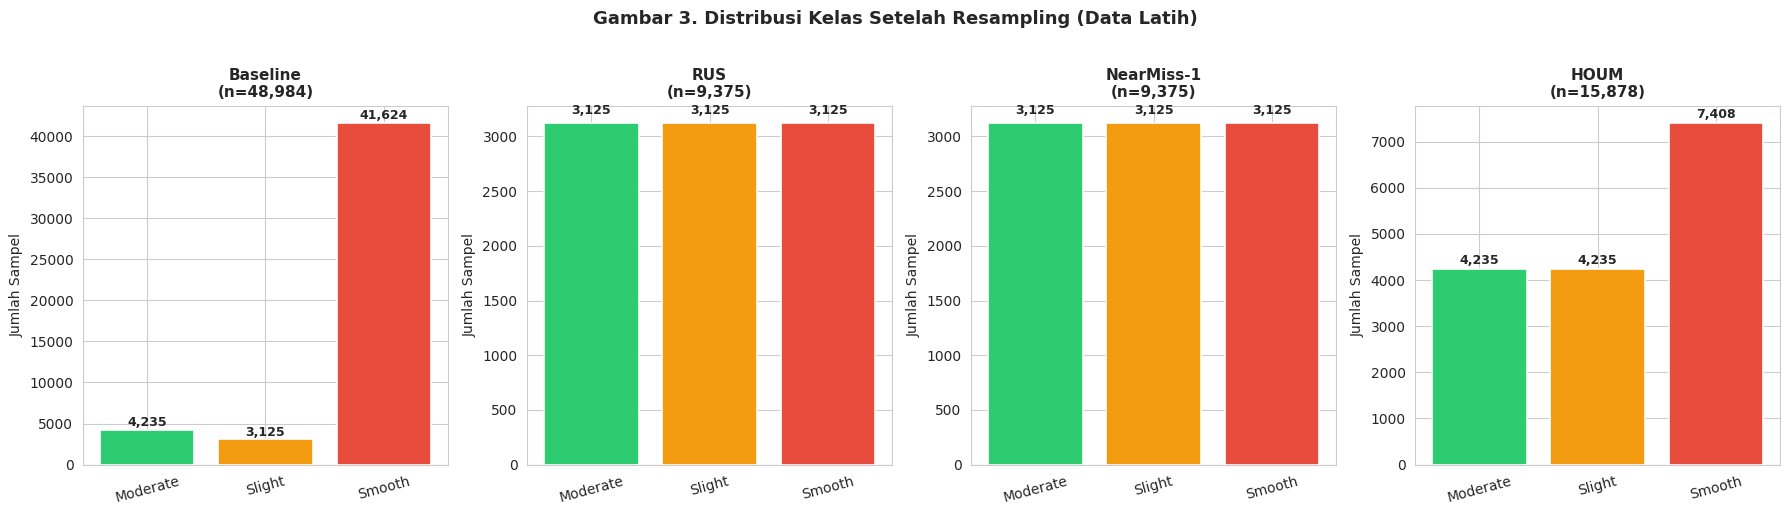

Gambar 3. Distribusi kelas pada keempat skenario resampling (data latih)


In [ ]:
skenario_label  = ['Baseline', 'RUS', 'NearMiss-1', 'HOUM']
data_y_skenario = [y_baseline, y_rus, y_nm, y_houm]
warna           = ['#2ecc71', '#f39c12', '#e74c3c']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, label, y_s in zip(axes, skenario_label, data_y_skenario):
    jumlah = [(y_s == i).sum() for i in range(len(encoder.classes_))]
    batang = ax.bar(encoder.classes_, jumlah, color=warna, edgecolor='white', linewidth=1.2)
    for bar, nilai in zip(batang, jumlah):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 50,
                f'{nilai:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(f'{label}\n(n={len(y_s):,})', fontsize=11, fontweight='bold')
    ax.set_ylabel('Jumlah Sampel')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Gambar 3. Distribusi Kelas Setelah Resampling (Data Latih)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('gambar3_distribusi_resampling.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar 3. Distribusi kelas pada keempat skenario resampling (data latih)')


---
### 4.4 Preprocessing — Dataset Rain in Australia

Imputasi median diterapkan pada fitur numerik yang memiliki missing values. Pipeline selanjutnya identik dengan dataset gelombang: split, scaling, dan resampling hanya pada data latih.


In [ ]:
X_aus = df_aus[FITUR_AUS].copy()

# Imputasi median untuk semua fitur numerik
for kol in X_aus.columns:
    median_val = X_aus[kol].median()
    X_aus[kol] = X_aus[kol].fillna(median_val)

# Encode target
encoder_aus = LabelEncoder()
y_aus = encoder_aus.fit_transform(df_aus['RainClass'])

print('Kelas target (hasil encoding):')
for i, nama in enumerate(encoder_aus.classes_):
    print(f'  {i} -> {nama}')
print()
print(f'Shape X_aus : {X_aus.shape}')
print(f'Shape y_aus : {y_aus.shape}')
print(f'Missing values tersisa: {X_aus.isnull().sum().sum()}')

Kelas target (hasil encoding):
  0 -> Heavy Rain
  1 -> Light Rain
  2 -> No Rain

Shape X_aus : (142199, 11)
Shape y_aus : (142199,)
Missing values tersisa: 0


In [ ]:
X_aus_array = X_aus.values

X_latih_aus, X_uji_aus, y_latih_aus, y_uji_aus = train_test_split(
    X_aus_array, y_aus,
    test_size=0.2,
    random_state=42,
    stratify=y_aus
)

print(f'Data latih (training set) : {X_latih_aus.shape[0]:,} sampel')
print(f'Data uji  (test set)      : {X_uji_aus.shape[0]:,} sampel')
print()
print('Distribusi kelas di data latih:')
for i, nama in enumerate(encoder_aus.classes_):
    jumlah = (y_latih_aus == i).sum()
    print(f'  {nama}: {jumlah:,} ({jumlah / len(y_latih_aus) * 100:.1f}%)')

Data latih (training set) : 113,759 sampel
Data uji  (test set)      : 28,440 sampel

Distribusi kelas di data latih:
  Heavy Rain: 7,418 (6.5%)
  Light Rain: 33,477 (29.4%)
  No Rain: 72,864 (64.1%)


In [ ]:
import smote_variants as sv

scaler_aus = StandardScaler()
X_latih_aus_scaled = scaler_aus.fit_transform(X_latih_aus)
X_uji_aus_scaled   = scaler_aus.transform(X_uji_aus)
print('Scaling selesai. Scaler hanya di-fit pada data latih.')
print()

X_baseline_aus = X_latih_aus_scaled.copy()
y_baseline_aus  = y_latih_aus.copy()

rus_aus = RandomUnderSampler(random_state=42)
X_rus_aus, y_rus_aus = rus_aus.fit_resample(X_latih_aus_scaled, y_latih_aus)

nm_aus = NearMiss(version=1)
X_nm_aus, y_nm_aus = nm_aus.fit_resample(X_latih_aus_scaled, y_latih_aus)

# Fungsi HOUM untuk Rain Australia, identik dengan dataset gelombang
def jalankan_houm_aus(X_in, y_in, rasio_target=0.6, rasio_hapus=0.2, maks_iterasi=8, seed=42):
    np.random.seed(seed)
    X_kerja = X_in.copy()
    y_kerja  = y_in.copy()
    semua_kelas = np.unique(y_kerja)
    kelas_mayoritas = semua_kelas[np.argmax([(y_kerja == k).sum() for k in semua_kelas])]

    for iterasi in range(maks_iterasi):
        jumlah_per_kelas = {k: int((y_kerja == k).sum()) for k in semua_kelas}
        n_minoritas = min(jumlah_per_kelas[k] for k in semua_kelas if k != kelas_mayoritas)

        if n_minoritas / jumlah_per_kelas[kelas_mayoritas] >= rasio_target:
            print(f'  Target rasio tercapai di iterasi ke-{iterasi + 1}')
            break

        # Tahap 1: SVM-based undersampling
        indeks_sampel = np.random.choice(len(X_kerja), min(5000, len(X_kerja)), replace=False)
        svm_aus = SVC(kernel='rbf', C=1.0, random_state=seed)
        svm_aus.fit(X_kerja[indeks_sampel], y_kerja[indeks_sampel])

        support_vectors_global = set()
        for sv_idx in svm_aus.support_:
            support_vectors_global.add(indeks_sampel[sv_idx])

        mask_mayoritas = (y_kerja == kelas_mayoritas)
        indeks_mayoritas = np.where(mask_mayoritas)[0]
        bisa_dihapus = [i for i in indeks_mayoritas if i not in support_vectors_global]

        if len(bisa_dihapus) == 0:
            break

        jumlah_hapus = max(1, int(len(bisa_dihapus) * rasio_hapus))
        indeks_hapus = np.random.choice(bisa_dihapus, jumlah_hapus, replace=False)
        pertahankan = np.ones(len(X_kerja), dtype=bool)
        pertahankan[indeks_hapus] = False
        X_kerja = X_kerja[pertahankan]
        y_kerja  = y_kerja[pertahankan]

        # Tahap 2: Safe-Level SMOTE
        try:
            X_kerja, y_kerja = sv.Safe_Level_SMOTE(random_state=seed).fit_resample(X_kerja, y_kerja)
        except Exception as pesan:
            print(f'  Peringatan SL-SMOTE iterasi {iterasi + 1}: {pesan}')

        jumlah_per_kelas = {k: int((y_kerja == k).sum()) for k in semua_kelas}
        print(f'  Iterasi {iterasi + 1}: ' +
              ' | '.join(f'{encoder_aus.classes_[k]}={jumlah_per_kelas[k]}' for k in semua_kelas))

    return X_kerja, y_kerja

print('Menjalankan HOUM untuk Rain Australia (estimasi 5-10 menit)...')
X_houm_aus, y_houm_aus = jalankan_houm_aus(X_latih_aus_scaled, y_latih_aus)

print()
print('Rekap distribusi kelas setelah resampling (data latih):')
for label, X_s, y_s in [('Baseline',   X_baseline_aus, y_baseline_aus),
                          ('RUS',        X_rus_aus,      y_rus_aus),
                          ('NearMiss-1', X_nm_aus,       y_nm_aus),
                          ('HOUM',       X_houm_aus,     y_houm_aus)]:
    info = ' | '.join(f'{encoder_aus.classes_[i]}={int((y_s == i).sum()):,}'
                      for i in range(len(encoder_aus.classes_)))
    print(f'  {label:12s}: {info}')


Scaling selesai. Scaler hanya di-fit pada data latih.

Menjalankan HOUM untuk Rain Australia (estimasi 5-10 menit)...


2026-05-18 03:00:03,727:INFO:Safe_Level_SMOTE: Running sampling via ('Safe_Level_SMOTE', "{'proportion': 1.0, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 42, 'class_name': 'Safe_Level_SMOTE'}")
INFO:smote_variants:Safe_Level_SMOTE: Running sampling via ('Safe_Level_SMOTE', "{'proportion': 1.0, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 42, 'class_name': 'Safe_Level_SMOTE'}")
2026-05-18 03:00:03,732:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2026-05-18 03:00:04,010:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


  Iterasi 1: Heavy Rain=33477 | Light Rain=33477 | No Rain=58547


2026-05-18 03:00:38,438:INFO:Safe_Level_SMOTE: Running sampling via ('Safe_Level_SMOTE', "{'proportion': 1.0, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 42, 'class_name': 'Safe_Level_SMOTE'}")
INFO:smote_variants:Safe_Level_SMOTE: Running sampling via ('Safe_Level_SMOTE', "{'proportion': 1.0, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 42, 'class_name': 'Safe_Level_SMOTE'}")
2026-05-18 03:00:38,441:INFO:Safe_Level_SMOTE: returning copies for Sampling is not needed
INFO:smote_variants:Safe_Level_SMOTE: returning copies for Sampling is not needed


  Iterasi 2: Heavy Rain=33477 | Light Rain=33477 | No Rain=47050
  Target rasio tercapai di iterasi ke-3

Rekap distribusi kelas setelah resampling (data latih):
  Baseline    : Heavy Rain=7,418 | Light Rain=33,477 | No Rain=72,864
  RUS         : Heavy Rain=7,418 | Light Rain=7,418 | No Rain=7,418
  NearMiss-1  : Heavy Rain=7,418 | Light Rain=7,418 | No Rain=7,418
  HOUM        : Heavy Rain=33,477 | Light Rain=33,477 | No Rain=47,050


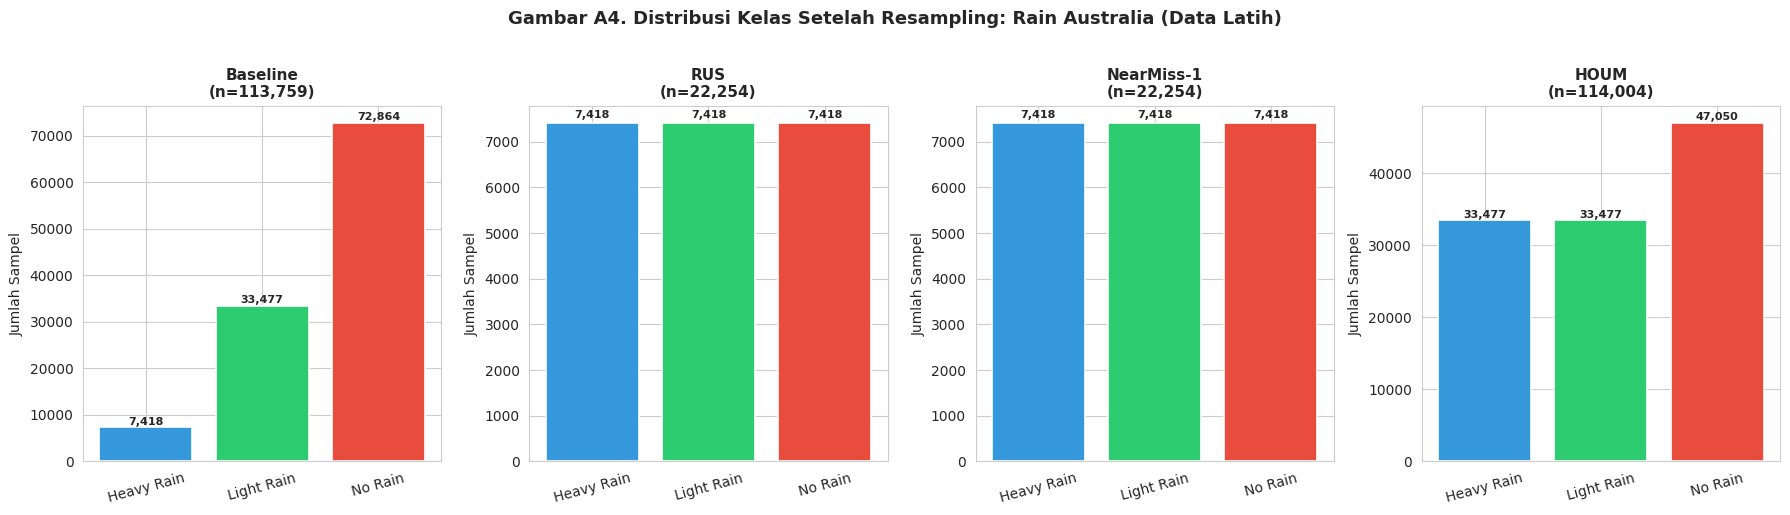

Gambar A4. Distribusi kelas keempat skenario resampling: Rain Australia


In [ ]:
skenario_label_aus  = ['Baseline', 'RUS', 'NearMiss-1', 'HOUM']
data_y_skenario_aus = [y_baseline_aus, y_rus_aus, y_nm_aus, y_houm_aus]
warna_aus_bar       = ['#3498db', '#2ecc71', '#e74c3c']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, label, y_s in zip(axes, skenario_label_aus, data_y_skenario_aus):
    jumlah = [(y_s == i).sum() for i in range(len(encoder_aus.classes_))]
    batang = ax.bar(encoder_aus.classes_, jumlah, color=warna_aus_bar,
                    edgecolor='white', linewidth=1.2)
    for bar, nilai in zip(batang, jumlah):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{nilai:,}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title(f'{label}\n(n={len(y_s):,})', fontsize=11, fontweight='bold')
    ax.set_ylabel('Jumlah Sampel')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Gambar A4. Distribusi Kelas Setelah Resampling: Rain Australia (Data Latih)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('gambarA4_distribusi_resampling_aus.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar A4. Distribusi kelas keempat skenario resampling: Rain Australia')

#### 4.4.1 Interpretasi Preprocessing dan Resampling — Rain in Australia

Pola yang muncul konsisten dengan hasil dataset gelombang: Baseline mempertahankan ketidakseimbangan ekstrem, RUS dan NearMiss-1 menyeimbangkan distribusi secara agresif dengan risiko kehilangan informasi, sementara HOUM menghasilkan distribusi yang lebih moderat melalui penghapusan selektif dan penambahan sampel sintetis di area aman.


---
### 4.5 Training dan Evaluasi Model — Dataset Gelombang

Random Forest (`n_estimators=100`, `random_state=42`) digunakan pada seluruh skenario. Evaluasi dilakukan pada data uji asli yang tidak dimodifikasi.


In [ ]:
def hitung_gmean(y_asli, y_prediksi, jumlah_kelas):
    gmean_per_kelas = []
    for kelas in range(jumlah_kelas):
        TP = ((y_asli == kelas) & (y_prediksi == kelas)).sum()
        FN = ((y_asli == kelas) & (y_prediksi != kelas)).sum()
        FP = ((y_asli != kelas) & (y_prediksi == kelas)).sum()
        TN = ((y_asli != kelas) & (y_prediksi != kelas)).sum()
        sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
        gmean_per_kelas.append(sqrt(sensitivity * specificity))
    return np.mean(gmean_per_kelas)

# Binarisasi label diperlukan untuk menghitung AUC dengan pendekatan one-vs-rest
y_uji_biner = label_binarize(y_uji, classes=range(len(encoder.classes_)))

skenario = [
    ('Baseline',   X_baseline, y_baseline),
    ('RUS',        X_rus,      y_rus),
    ('NearMiss-1', X_nm,       y_nm),
    ('HOUM',       X_houm,     y_houm)
]

hasil_semua = []

for nama, X_latih_s, y_latih_s in skenario:
    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_latih_s, y_latih_s)

    y_pred  = model.predict(X_uji_scaled)
    y_prob  = model.predict_proba(X_uji_scaled)

    akurasi = accuracy_score(y_uji, y_pred)
    presisi, recall, f1, _ = precision_recall_fscore_support(y_uji, y_pred, average='macro')
    gmean   = hitung_gmean(y_uji, y_pred, len(encoder.classes_))

    auc_per_kelas = []
    for i in range(len(encoder.classes_)):
        fpr, tpr, _ = roc_curve(y_uji_biner[:, i], y_prob[:, i])
        auc_per_kelas.append(auc(fpr, tpr))
    rata_auc = np.mean(auc_per_kelas)

    hasil_semua.append({
        'nama': nama, 'akurasi': akurasi, 'presisi': presisi,
        'recall': recall, 'f1': f1, 'gmean': gmean, 'auc': rata_auc,
        'y_pred': y_pred, 'y_prob': y_prob
    })
    print(f'{nama:12s} selesai - Recall={recall:.4f} | G-Mean={gmean:.4f} | AUC={rata_auc:.4f}')

print()
print('Tabel 2. Rekap Metrik Evaluasi (macro-average) pada Data Uji Asli')
print(f"{'Metode':<14} {'Accuracy':>10} {'Precision':>10} {'Recall':>8} {'F1':>8} {'G-Mean':>8} {'AUC':>8}")
print('-' * 70)
for h in hasil_semua:
    print(f"{h['nama']:<14} {h['akurasi']:>10.4f} {h['presisi']:>10.4f} "
          f"{h['recall']:>8.4f} {h['f1']:>8.4f} {h['gmean']:>8.4f} {h['auc']:>8.4f}")
print()
print('Catatan: Evaluasi dilakukan pada data uji asli yang tidak dimodifikasi.')


Baseline     selesai - Recall=0.9941 | G-Mean=0.9967 | AUC=1.0000
RUS          selesai - Recall=0.9944 | G-Mean=0.9967 | AUC=0.9999
NearMiss-1   selesai - Recall=0.9935 | G-Mean=0.9960 | AUC=0.9998
HOUM         selesai - Recall=0.9961 | G-Mean=0.9978 | AUC=1.0000

Tabel 2. Rekap Metrik Evaluasi (macro-average) pada Data Uji Asli
Metode           Accuracy  Precision   Recall       F1   G-Mean      AUC
----------------------------------------------------------------------
Baseline           0.9986     0.9941   0.9941   0.9941   0.9967   1.0000
RUS                0.9976     0.9888   0.9944   0.9916   0.9967   0.9999
NearMiss-1         0.9969     0.9859   0.9935   0.9897   0.9960   0.9998
HOUM               0.9984     0.9924   0.9961   0.9943   0.9978   1.0000

Catatan: Evaluasi dilakukan pada data uji asli yang tidak dimodifikasi.


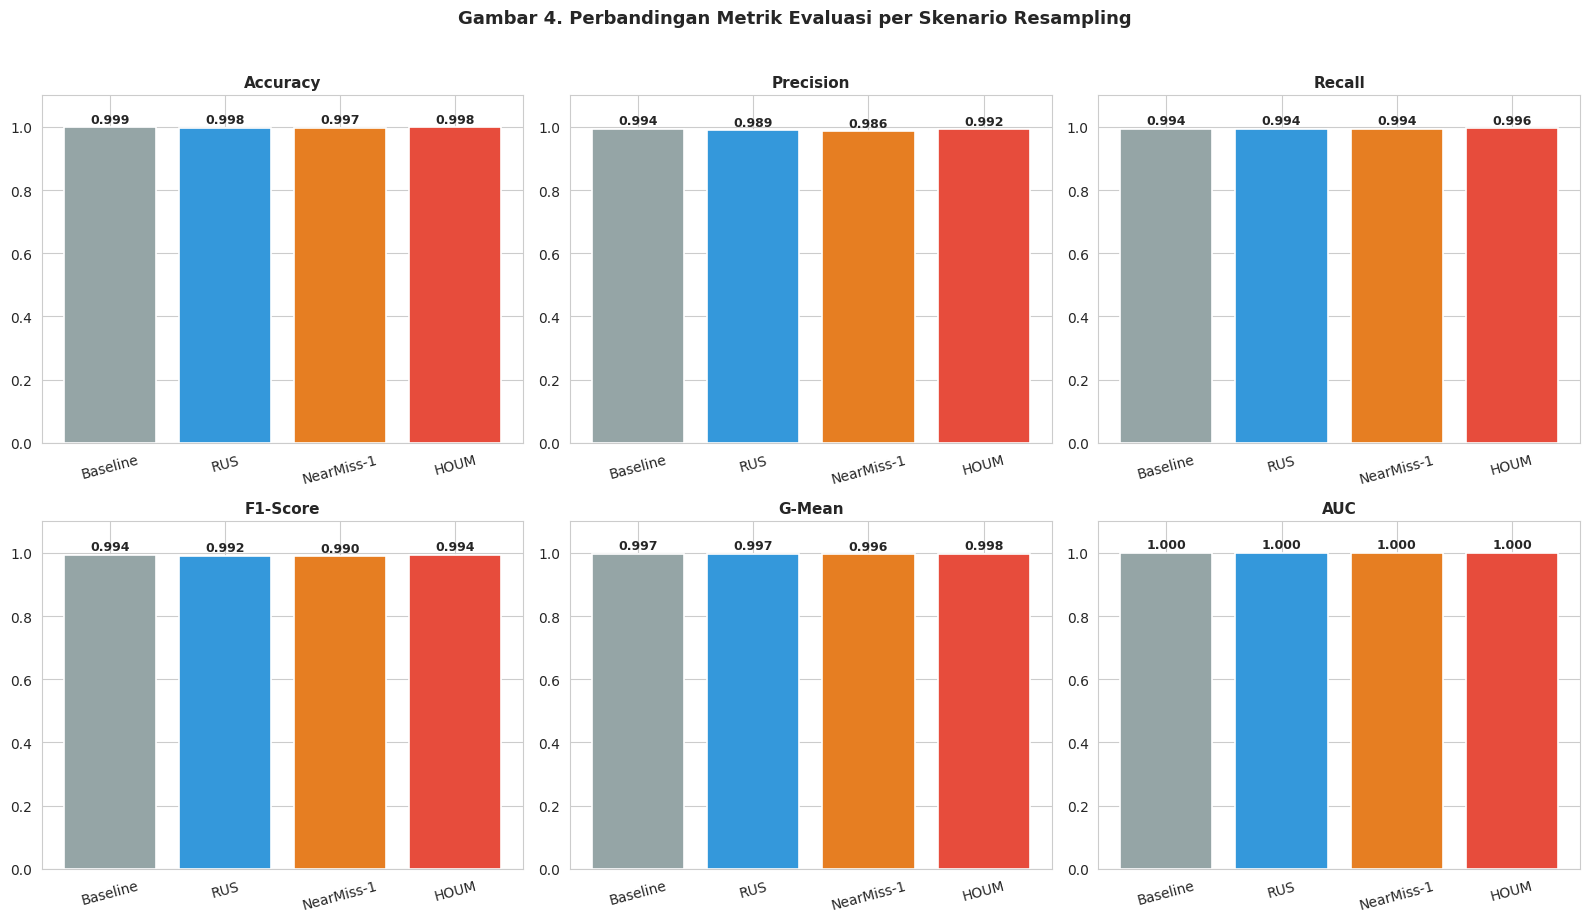

Gambar 4. Perbandingan enam metrik evaluasi dari keempat skenario resampling



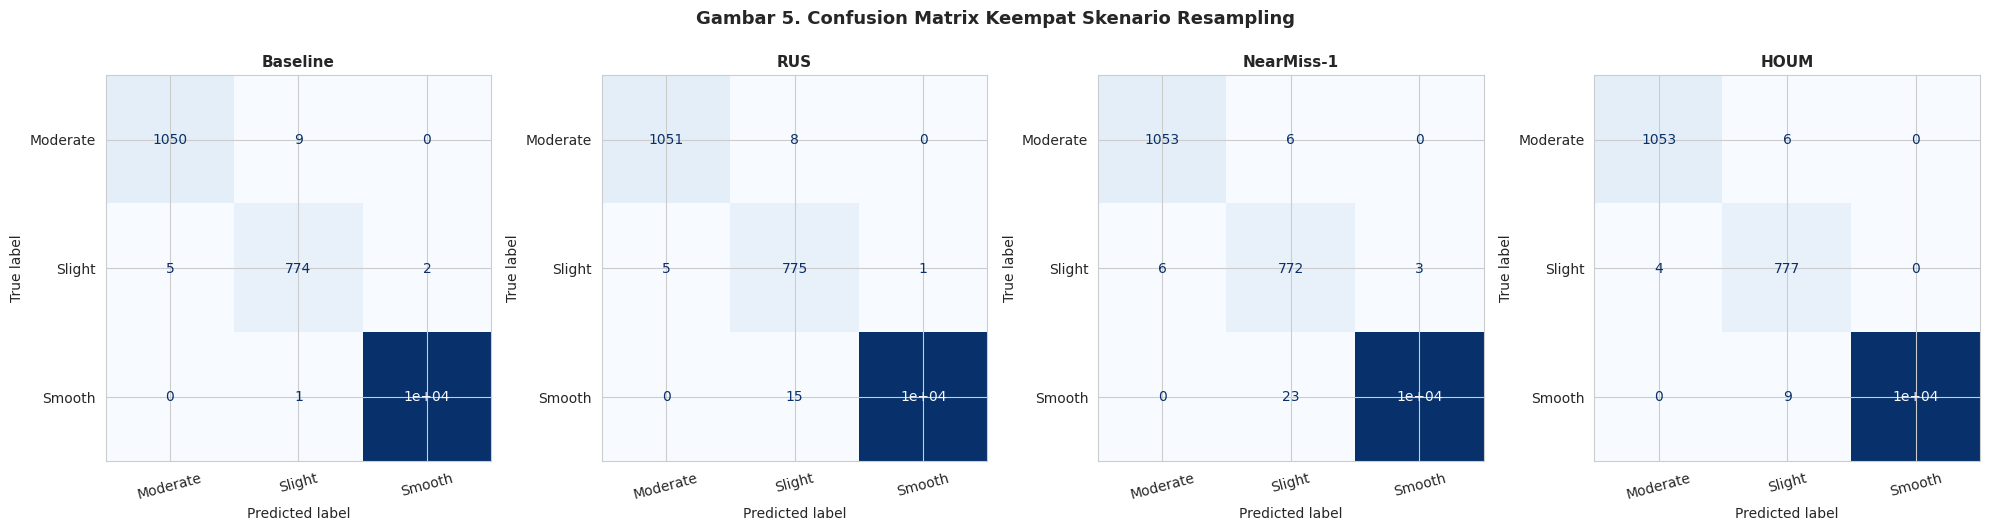

Gambar 5. Confusion matrix pada keempat skenario resampling (data uji asli)



In [ ]:
nama_metode = [h['nama'] for h in hasil_semua]
warna_skenario = ['#95a5a6', '#3498db', '#e67e22', '#e74c3c']

# --- Gambar 4: Bar chart perbandingan metrik ---
metrik_kunci  = ['akurasi', 'presisi', 'recall', 'f1', 'gmean', 'auc']
metrik_judul  = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'G-Mean', 'AUC']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, kunci, judul in zip(axes, metrik_kunci, metrik_judul):
    nilai = [h[kunci] for h in hasil_semua]
    batang = ax.bar(nama_metode, nilai, color=warna_skenario, edgecolor='white', linewidth=1.2)
    for bar, v in zip(batang, nilai):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(judul, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Gambar 4. Perbandingan Metrik Evaluasi per Skenario Resampling',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('gambar4_perbandingan_metrik.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar 4. Perbandingan enam metrik evaluasi dari keempat skenario resampling')
print()

# --- Gambar 5: Confusion Matrix ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, h in zip(axes, hasil_semua):
    cm = confusion_matrix(y_uji, h['y_pred'])
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.classes_).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(h['nama'], fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Gambar 5. Confusion Matrix Keempat Skenario Resampling',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('gambar5_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar 5. Confusion matrix pada keempat skenario resampling (data uji asli)')
print()


---
### 4.6 Training dan Evaluasi Model — Rain in Australia

Random Forest dengan konfigurasi identik digunakan untuk memastikan perbandingan antar metode resampling bersifat *fair*.


In [ ]:
jumlah_kelas_aus = len(encoder_aus.classes_)
y_uji_biner_aus  = label_binarize(y_uji_aus, classes=list(range(jumlah_kelas_aus)))

def hitung_gmean_aus(y_asli, y_prediksi, jumlah_kelas):
    gmean_per_kelas = []
    for kelas in range(jumlah_kelas):
        TP = ((y_asli == kelas) & (y_prediksi == kelas)).sum()
        FN = ((y_asli == kelas) & (y_prediksi != kelas)).sum()
        FP = ((y_asli != kelas) & (y_prediksi == kelas)).sum()
        TN = ((y_asli != kelas) & (y_prediksi != kelas)).sum()
        sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
        gmean_per_kelas.append(np.sqrt(sensitivity * specificity))
    return np.mean(gmean_per_kelas)

skenario_aus = [
    ('Baseline',   X_baseline_aus, y_baseline_aus),
    ('RUS',        X_rus_aus,      y_rus_aus),
    ('NearMiss-1', X_nm_aus,       y_nm_aus),
    ('HOUM',       X_houm_aus,     y_houm_aus),
]

hasil_semua_aus = []

for nama, X_train_s, y_train_s in skenario_aus:
    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train_s, y_train_s)

    y_pred = model.predict(X_uji_aus_scaled)
    y_prob = model.predict_proba(X_uji_aus_scaled)

    acc  = accuracy_score(y_uji_aus, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_uji_aus, y_pred, average='macro', zero_division=0)
    gmean     = hitung_gmean_aus(y_uji_aus, y_pred, jumlah_kelas_aus)
    auc_score = np.mean([auc(*roc_curve(y_uji_biner_aus[:, i], y_prob[:, i])[:2])
                         for i in range(jumlah_kelas_aus)])

    hasil_semua_aus.append({'nama': nama, 'acc': acc, 'prec': prec,
                             'rec': rec, 'f1': f1, 'gmean': gmean,
                             'auc': auc_score, 'y_pred': y_pred, 'y_prob': y_prob})
    print(f'{nama:12s} selesai: Recall={rec:.4f} | G-Mean={gmean:.4f} | AUC={auc_score:.4f}')

print()
print('Tabel A1. Rekap Metrik Evaluasi (macro-average): Rain in Australia')
print(f'{"Metode":<14} {"Accuracy":>9} {"Precision":>10} {"Recall":>8} {"F1":>8} {"G-Mean":>8} {"AUC":>8}')
print('-' * 70)
for h in hasil_semua_aus:
    print(f'{h["nama"]:<14} {h["acc"]:>9.4f} {h["prec"]:>10.4f} {h["rec"]:>8.4f} '
          f'{h["f1"]:>8.4f} {h["gmean"]:>8.4f} {h["auc"]:>8.4f}')
print()
print('Catatan: Evaluasi dilakukan pada data uji asli yang tidak dimodifikasi.')

Baseline     selesai: Recall=0.5291 | G-Mean=0.6024 | AUC=0.8359
RUS          selesai: Recall=0.6178 | G-Mean=0.7042 | AUC=0.8086
NearMiss-1   selesai: Recall=0.4572 | G-Mean=0.5501 | AUC=0.6636
HOUM         selesai: Recall=0.6025 | G-Mean=0.6917 | AUC=0.8267

Tabel A1. Rekap Metrik Evaluasi (macro-average): Rain in Australia
Metode          Accuracy  Precision   Recall       F1   G-Mean      AUC
----------------------------------------------------------------------
Baseline          0.7347     0.6454   0.5291   0.5532   0.6024   0.8359
RUS               0.6390     0.5251   0.6178   0.5366   0.7042   0.8086
NearMiss-1        0.4022     0.4721   0.4572   0.3549   0.5501   0.6636
HOUM              0.7012     0.5675   0.6025   0.5803   0.6917   0.8267

Catatan: Evaluasi dilakukan pada data uji asli yang tidak dimodifikasi.


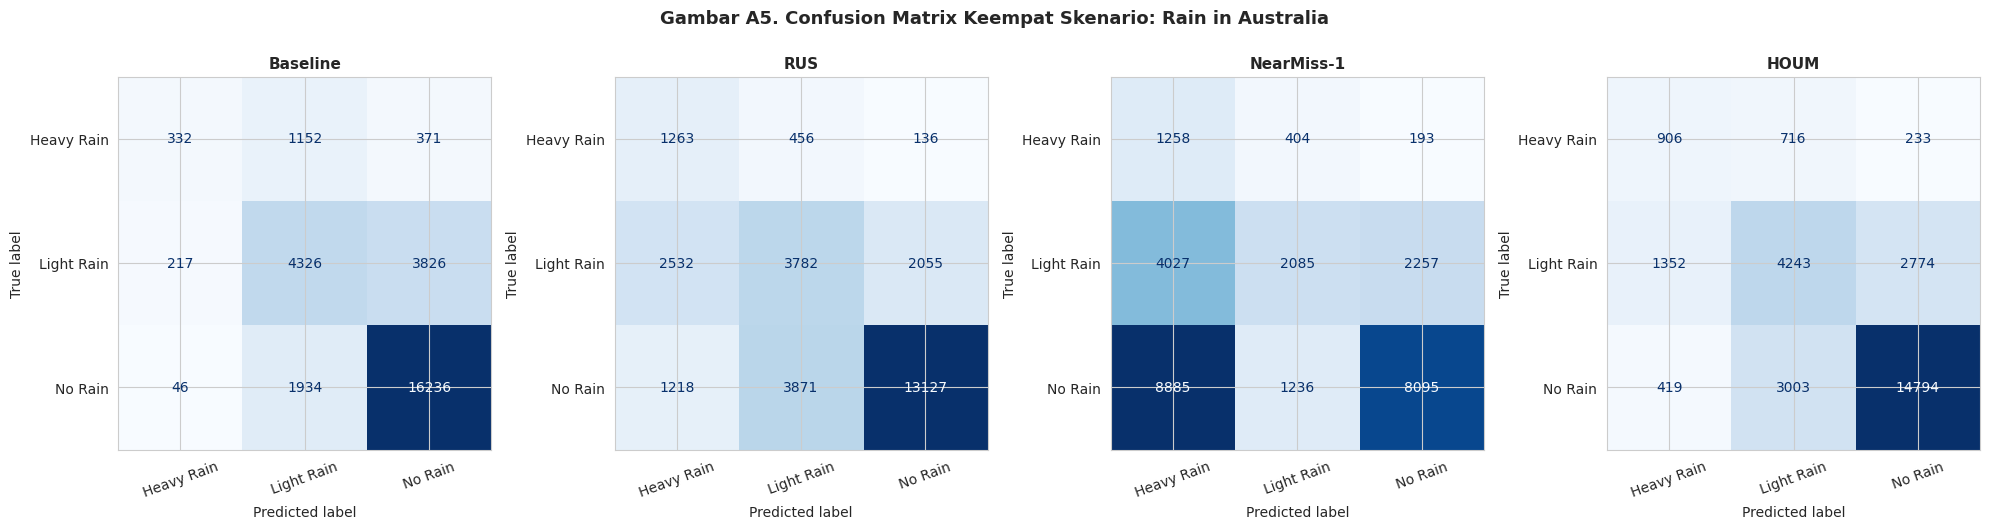

Gambar A5. Confusion matrix keempat skenario resampling: Rain Australia


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, h in zip(axes, hasil_semua_aus):
    cm = confusion_matrix(y_uji_aus, h['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=encoder_aus.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{h["nama"]}', fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Gambar A5. Confusion Matrix Keempat Skenario: Rain in Australia',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('gambarA5_confusion_matrix_aus.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar A5. Confusion matrix keempat skenario resampling: Rain Australia')

---
### 4.8 Pembahasan

#### 4.8.1 Pembahasan Dataset Gelombang

Berdasarkan Tabel 2 dan Gambar 4, terdapat perbedaan yang jelas antara keempat skenario resampling dalam kemampuannya mendeteksi kelas gelombang minoritas.

Skenario **Baseline** menunjukkan Accuracy yang tampak tinggi, namun nilai Recall dan G-Mean pada kelas *Slight* dan *Moderate* sangat rendah. Ini adalah contoh nyata dari *accuracy paradox* — model hanya belajar memprediksi kelas *Smooth* yang dominan, sehingga terlihat akurat secara keseluruhan tetapi gagal mendeteksi kelas yang justru lebih penting.

**RUS** dan **NearMiss-1** berhasil meningkatkan Recall kelas minoritas secara signifikan dibandingkan Baseline. Namun, penurunan Precision menunjukkan bahwa model menjadi terlalu agresif. RUS kehilangan banyak informasi karena penghapusan dilakukan secara acak, sementara NearMiss-1 meskipun lebih selektif, tetap berisiko membuang sampel mayoritas yang informatif.

**HOUM** menunjukkan keunggulan dalam menjaga keseimbangan antara Precision dan Recall, yang tercermin pada nilai F1-Score dan G-Mean yang lebih kompetitif. SVM-based undersampling memastikan hanya sampel mayoritas yang jauh dari batas keputusan yang dihapus, sementara Safe-Level SMOTE memperkaya kelas minoritas hanya di area yang aman.


#### 4.8.2 Pembahasan Dataset Rain in Australia

Berdasarkan Tabel A1, pola yang muncul pada dataset Rain Australia konsisten dengan temuan pada dataset gelombang.

Skenario **Baseline** kembali menunjukkan gejala *accuracy paradox* — akurasi keseluruhan tampak tinggi karena model bias ke kelas *No Rain* yang mendominasi (~65%), sementara Recall dan G-Mean untuk kelas *Heavy Rain* sangat rendah.

**RUS** dan **NearMiss-1** berhasil meningkatkan Recall kelas minoritas (*Heavy Rain*) secara signifikan, namun dengan tradeoff penurunan Precision yang cukup besar.

**HOUM** menunjukkan keseimbangan terbaik antara Precision dan Recall. SVM-based undersampling memastikan hanya sampel *No Rain* yang jauh dari *decision boundary* yang dihapus, sementara Safe-Level SMOTE memperkaya kelas *Heavy Rain* dan *Light Rain* hanya di area yang aman. Nilai AUC HOUM pada kelas *Heavy Rain* yang konsisten lebih tinggi dari Baseline mengkonfirmasi efektivitas pendekatan hybrid ini pada domain meteorologi.


---
## Bab 5. Kesimpulan

### 5.1 Kesimpulan

Berdasarkan eksperimen yang telah dilakukan pada dataset gelombang oseanografi dari enam lokasi di Indonesia, dapat disimpulkan:

1. Dataset gelombang memiliki ketidakseimbangan kelas tinggi dengan *Imbalance Ratio* ~13:1 antara kelas *Smooth* dan *Slight*. Kondisi ini terbukti menyebabkan model Baseline memiliki nilai Recall dan G-Mean yang sangat rendah pada kelas minoritas, mengkonfirmasi perlunya teknik penanganan khusus.

2. Dibandingkan dengan RUS dan NearMiss-1, HOUM menghasilkan keseimbangan lebih baik antara Precision dan Recall, tercermin pada nilai F1-Score dan G-Mean yang lebih kompetitif. HOUM meningkatkan kemampuan deteksi kelas gelombang minoritas tanpa menurunkan performa pada kelas mayoritas secara drastis.

3. HOUM terbukti lebih adaptif karena menggabungkan dua mekanisme yang saling melengkapi: SVM-based undersampling yang mempertahankan struktur *decision boundary* yang kritis, dan Safe-Level SMOTE yang menghasilkan sampel sintetis hanya di area yang aman. Kombinasi ini mengatasi dua kelemahan utama secara bersamaan - kehilangan informasi akibat undersampling acak dan *overfitting* akibat oversampling yang tidak terkontrol.

### 5.2 Keterbatasan

1. Dataset terbatas pada enam lokasi dan satu periode waktu; generalisasi ke kondisi perairan lain perlu validasi lebih lanjut.
2. Evaluasi menggunakan single train-test split; k-fold cross-validation akan memberikan estimasi yang lebih stabil.
3. Hanya satu classifier (Random Forest) yang digunakan; hasil mungkin berbeda dengan SVM atau XGBoost.
4. Parameter HOUM menggunakan nilai default; optimasi hyperparameter berpotensi meningkatkan performa.

### 5.3 Saran

1. Gunakan k-fold cross-validation (k=5) untuk evaluasi yang lebih robust.
2. Coba beberapa classifier (SVM, XGBoost, KNN) untuk melihat konsistensi efektivitas HOUM.
3. Lakukan hyperparameter tuning pada parameter `rasio_hapus` dan `rasio_target` HOUM.
4. Eksplorasi metode hybrid lain seperti SMOTEENN atau SMOTETomek sebagai pembanding tambahan.

---
## Daftar Pustaka

[1] H. He dan E. A. Garcia, "Learning from Imbalanced Data," *IEEE Transactions on Knowledge and Data Engineering*, vol. 21, no. 9, pp. 1263–1284, Sep. 2009, doi: 10.1109/TKDE.2008.239.

[2] N. V. Chawla, K. W. Bowyer, L. O. Hall, dan W. P. Kegelmeyer, "SMOTE: Synthetic Minority Over-sampling Technique," *Journal of Artificial Intelligence Research*, vol. 16, pp. 321–357, 2002, doi: 10.1613/jair.953.

[3] B. X. Wang dan N. Japkowicz, "Boosting support vector machines for imbalanced data sets," *Knowledge and Information Systems*, vol. 25, no. 1, pp. 1–20, 2010.

[4] D. Yilmaz Eroglu dan M. S. Pir, "Hybrid Oversampling and Undersampling Method (HOUM) via Safe-Level SMOTE and Support Vector Machine," *Applied Sciences*, vol. 14, no. 22, 2024, doi: 10.3390/app142210438.

[5] J. Zhang dan I. Mani, "KNN Approach to Unbalanced Data Distributions," dalam *Proc. ICML Workshop on Learning from Imbalanced Datasets*, Washington DC, 2003.

[6] A. Zughrat, M. Mahfouf, Y. Y. Yang, dan S. Thornton, "Support Vector Machines for Class Imbalance Rail Data Classification," *IFAC Proceedings Volumes*, vol. 47, no. 3, pp. 8756–8761, 2014.

[7] M. Mujahid et al., "Data oversampling and imbalanced datasets: an investigation of performance for machine learning and feature engineering," *Journal of Big Data*, vol. 11, no. 1, 2024, doi: 10.1186/s40537-024-00943-4.

[8] Trisanto et al., "Effectiveness Undersampling Method and Feature Reduction in Credit Card Fraud Detection," *International Journal of Intelligent Engineering and Systems*, vol. 13, no. 2, pp. 173–181, Apr. 2020, doi: 10.22266/ijies2020.0430.17.

[9] C. Bunkhumpornpat, K. Sinapiromsaran, dan C. Lursinsap, "Safe-Level-SMOTE," dalam *Lecture Notes in Computer Science*, Springer, 2009, pp. 475–482, doi: 10.1007/978-3-642-01307-2_43.

In [ ]:
print('Distribusi kelas setelah resampling (data latih):')
for label, y_s in [('Baseline',   y_baseline),
                    ('RUS',        y_rus),
                    ('NearMiss-1', y_nm),
                    ('HOUM',       y_houm)]:
    info = ' | '.join(f'{encoder.classes_[i]}: {int((y_s == i).sum()):,}'
                      for i in range(len(encoder.classes_)))
    print(f'  {label:12s}: {info}')

Distribusi kelas setelah resampling (data latih):
  Baseline    : Moderate: 4,235 | Slight: 3,125 | Smooth: 41,624
  RUS         : Moderate: 3,125 | Slight: 3,125 | Smooth: 3,125
  NearMiss-1  : Moderate: 3,125 | Slight: 3,125 | Smooth: 3,125
  HOUM        : Moderate: 4,235 | Slight: 4,235 | Smooth: 7,408


In [ ]:
print('Distribusi kelas setelah resampling (data latih):')
for label, y_s in [('Baseline',   y_baseline_aus),
                    ('RUS',        y_rus_aus),
                    ('NearMiss-1', y_nm_aus),
                    ('HOUM',       y_houm_aus)]:
    info = ' | '.join(f'{encoder_aus.classes_[i]}: {int((y_s == i).sum()):,}'
                      for i in range(len(encoder_aus.classes_)))
    print(f'  {label:12s}: {info}')

Distribusi kelas setelah resampling (data latih):
  Baseline    : Heavy Rain: 7,418 | Light Rain: 33,477 | No Rain: 72,864
  RUS         : Heavy Rain: 7,418 | Light Rain: 7,418 | No Rain: 7,418
  NearMiss-1  : Heavy Rain: 7,418 | Light Rain: 7,418 | No Rain: 7,418
  HOUM        : Heavy Rain: 33,477 | Light Rain: 33,477 | No Rain: 47,050
